In [1]:
import sys
sys.path.insert(1, '/home/bricej/MyPythonLibrary/StageM2_IVT/library/')
import domain
from domain import *
from climbas import *
import numpy as np
import xarray as xr
import pandas as pd
from netCDF4 import Dataset
import dask
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import calendar

# Period & Domain

In [2]:
iyear=1981
fyear=2015
dom='HMA'
latS,latN,lonW,lonE,latlim,lonlim = coord_domain('HMA')

# Precipitation datas loading

In [3]:
#####################  APHRO  #####################################

model1='aphro'
res1=str('0.25°x0.25°')
ds1 = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/aphro/monthly/APHRO_mon_MA_025deg_V1101_EXR1.1951-2015.nc'
                      ,decode_times=False)['precip']
start_date = pd.Timestamp('1951-01-01')
# Create new time index
nmonths = ds1.time.size
time_new = pd.date_range(start=start_date, periods=nmonths, freq='MS')  # 'MS' = Month Start
# Replace time in dataset
ds1['time'] = time_new
ds1=reversing_lat(ds1)
ds1=ds1.rename({'latitude':'lat','longitude':'lon'})
field1_mm_day=field_dom(ds1,dom)
field1_mm_day=field1_mm_day.sel(time=slice(str(iyear),str(fyear)))

# Convert mm/day to mm/month
days_in_month = field1_mm_day['time'].dt.days_in_month
field1= field1_mm_day * days_in_month


In [4]:
ds1_SH_raw=xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/gmted/'+'gmted_on_aphro.nc')['elevation']
ds1_SH=ds1_SH_raw.rename({'latitude':'lat','longitude':'lon'})
ds1_SH=reversing_lat(ds1_SH)
field1_SH=field_dom(ds1_SH,dom)

In [5]:
#####################  GPCP  #####################################

model2='gpcp'
res2=str('1.0°x1.0°')
ds2= xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/gpcp/precip_mon.gpcp_v2020_1891_2019_10.nc')['precip']

field2=field_dom(ds2,dom)
field2=field2.sel(time=slice(str(iyear),str(fyear)))

In [6]:
ds2_SH=xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/gmted/'+'gmted_on_gpcp.nc')['elevation']
field2_SH=field_dom(ds2_SH,dom)

In [7]:
#####################  CRU  #####################################

model3='cru'
res3=str('0.5°x0.5°')

ds3_raw= xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/cru/cru_ts4.05.1901.2020.pre.dat.nc')['pre']
ds3=reversing_lat(ds3_raw)
field3=field_dom(ds3,dom)
field3=field3.sel(time=slice(str(iyear),str(fyear)))


In [8]:
ds3_SH_raw=xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/gmted/gmted_on_cru_hma_grid.nc')['elevation']
ds3_SH=reversing_lat(ds3_SH_raw)
field3_SH=field_dom(ds3_SH,dom)

In [9]:
#####################  CHIRPS  #####################################

model4='chirps'
res4='0.05°x0.05°'

ds4 = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/chirps/chirps-v2.0.monthly.nc')['precip']
ds4=ds4.rename({'latitude':'lat','longitude':'lon'})
ds4=reversing_lat(ds4)
field4=field_dom(ds4,dom)
field4=field4.sel(time=slice(str(iyear),str(fyear)))


In [10]:
ds4_SH=xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/gmted/'+'gmted_on_chirps_hma_grid.nc')['elevation']
ds4_SH=ds4_SH.rename({'latitude':'lat','longitude':'lon'})
ds4_SH=reversing_lat(ds4_SH)
field4_SH=field_dom(ds4_SH,dom)

In [11]:
#####################  HARv2  #####################################

model5='HARv2'
res5='10kmx10km'

ds5_raw0= xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/HARv2/HARv2_mon_d10km_d_2d_prcp_1980-2023.nc')['prcp']
ds5_raw=ds5_raw0*24 #mm/h
# Calculate days in each month
days_in_month5= ds5_raw['time'].dt.days_in_month
# Convert to mm/month
ds5= ds5_raw* days_in_month5

def xy_sel_dom(ds,latS,latN,lonW,lonE):
    #latS,latN,lonW,lonE,latlim,lonlim=coord_domain(domain)
    lat_str = ''
    lon_str = ''
    other_dims_str = []
    for dim in ds.coords:
        print(dim)
        if dim in ['lat', 'latitude','LON']:
            lat_str = dim
        elif dim in ['lon', 'longitude','LAT']:
            lon_str = dim
        else:
            other_dims_str.append(dim)
    mask = (
        (latS < ds[lat_str]) & ( ds[lat_str] < latN) 
    & (lonW < ds[lon_str]) & ( ds[lon_str] < lonE)
    )
    field_dom=ds.where(mask,drop=True)
    return field_dom

# Apply mask (non-NaN where the condition is True)
field5=xy_sel_dom(ds5.sel(time=slice(str(iyear),str(fyear))),latS,latN,lonW,lonE)

time
lon
lat
west_east
south_north


In [12]:
ds5_grM= xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/HARv2/HARv2_d10km_static_hgt.nc')
ds5_SH=ds5_grM['hgt'][0,:,:]
field5_SH=xy_sel_dom(ds5_SH,latS,latN,lonW,lonE)

time
west_east
south_north
lon
lat


In [13]:
#####################  ERA5  #####################################

model6='era5'
res6=str('0.25°x0.25°')

ds6_raw= xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/era5/'
                         +'tp.mon_era5_1940-2025_NH_025x025.nc')['tp']
ds6=ds6_raw.rename({'valid_time': 'time','latitude':'lat','longitude':'lon'})
ds6=ds6.sel(time=slice(str(iyear),str(fyear)))

field6_m_day=field_dom(ds6,dom)

# Convert m/day to mm/month
days_in_month = field6_m_day['time'].dt.days_in_month
field6= field6_m_day * days_in_month * 1000



In [14]:
ds6_SH=xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/gmted/gmted_on_era5_grid.nc')['elevation']
ds6_SH=ds6_SH.rename({'latitude':'lat','longitude':'lon'})
field6_SH=field_dom(ds6_SH,dom)

# Annual Climatology

In [15]:
models = ['APHRO','GPCP','CRU','CHIRPS','HARv2','ERA5']

In [16]:
tp_mean1 = field1.mean(dim='time', skipna=True)

In [17]:
tp_mean2 = field2.mean(dim='time', skipna=True)

In [18]:
tp_mean3 = field3.mean(dim='time', skipna=True)

In [21]:
#field4 = field4.chunk({"time": 12})
tp_mean4 = field4.mean(dim='time', skipna=True)
#tp_mean4 = tp_mean4.compute()

In [19]:
tp_mean5 = field5.mean(dim='time', skipna=True)

In [20]:
tp_mean6 = field6.mean(dim='time', skipna=True)

In [22]:
tp_mean_dict = {
    models[0]: tp_mean1,
    models[1]: tp_mean2,
    models[2]: tp_mean3,
    models[3]: tp_mean4,
    models[4]: tp_mean5,
    models[5]: tp_mean6}

In [16]:
field_SH_dict = {
    models[0]: field1_SH,
    models[1]: field2_SH,
    models[2]: field3_SH,
    models[3]: field4_SH,
    models[4]: field5_SH,
    models[5]: field6_SH}

In [54]:
output_dir = '/bettik/PROJECTS/pr-regional-climate/bricej/climbas/'

for model, data in tp_mean_dict.items():
    
    ds = data.to_dataset(name="tp")
    ds.attrs["units"] = "mm/month"
    ds.attrs["long_name"] = "Annual mean precipitation"
    ds.attrs["description"] = "Climatological annual mean over 1981–2015 in HMA"
    
    filename = f"{output_dir}/spatial_mean_tp_annual_{dom}_{iyear}-{fyear}_{model}.nc"
    
    ds.to_netcdf(filename)

    print(f'Saved file : {filename}')

Saved file : /bettik/PROJECTS/pr-regional-climate/bricej/climbas//spatial_mean_tp_annual_HMA_1981-2015_APHRO.nc
Saved file : /bettik/PROJECTS/pr-regional-climate/bricej/climbas//spatial_mean_tp_annual_HMA_1981-2015_GPCP.nc
Saved file : /bettik/PROJECTS/pr-regional-climate/bricej/climbas//spatial_mean_tp_annual_HMA_1981-2015_CRU.nc
Saved file : /bettik/PROJECTS/pr-regional-climate/bricej/climbas//spatial_mean_tp_annual_HMA_1981-2015_CHIRPS.nc
Saved file : /bettik/PROJECTS/pr-regional-climate/bricej/climbas//spatial_mean_tp_annual_HMA_1981-2015_HARv2.nc
Saved file : /bettik/PROJECTS/pr-regional-climate/bricej/climbas//spatial_mean_tp_annual_HMA_1981-2015_ERA5.nc


In [35]:
models = ['APHRO','GPCP','CRU','CHIRPS','HARv2','ERA5']

model1='APHRO'
tp_mean1 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/climbas/spatial_mean_tp_annual_{dom}_{iyear}-{fyear}_{model1}.nc')['tp']

model2='GPCP'
tp_mean2 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/climbas/spatial_mean_tp_annual_{dom}_{iyear}-{fyear}_{model2}.nc')['tp']

model3='CRU'
tp_mean3 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/climbas/spatial_mean_tp_annual_{dom}_{iyear}-{fyear}_{model3}.nc')['tp']

model4='CHIRPS'
tp_mean4 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/climbas/spatial_mean_tp_annual_{dom}_{iyear}-{fyear}_{model4}.nc')['tp']

model5='HARv2'
tp_mean5 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/climbas/spatial_mean_tp_annual_{dom}_{iyear}-{fyear}_{model5}.nc')['tp']

model6='ERA5'
tp_mean6 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/climbas/spatial_mean_tp_annual_{dom}_{iyear}-{fyear}_{model6}.nc')['tp']

tp_mean_dict = {
    models[0]: tp_mean1,
    models[1]: tp_mean2,
    models[2]: tp_mean3,
    models[3]: tp_mean4,
    models[4]: tp_mean5,
    models[5]: tp_mean6}

field_SH_dict = {
    models[0]: field1_SH,
    models[1]: field2_SH,
    models[2]: field3_SH,
    models[3]: field4_SH,
    models[4]: field5_SH,
    models[5]: field6_SH}

500


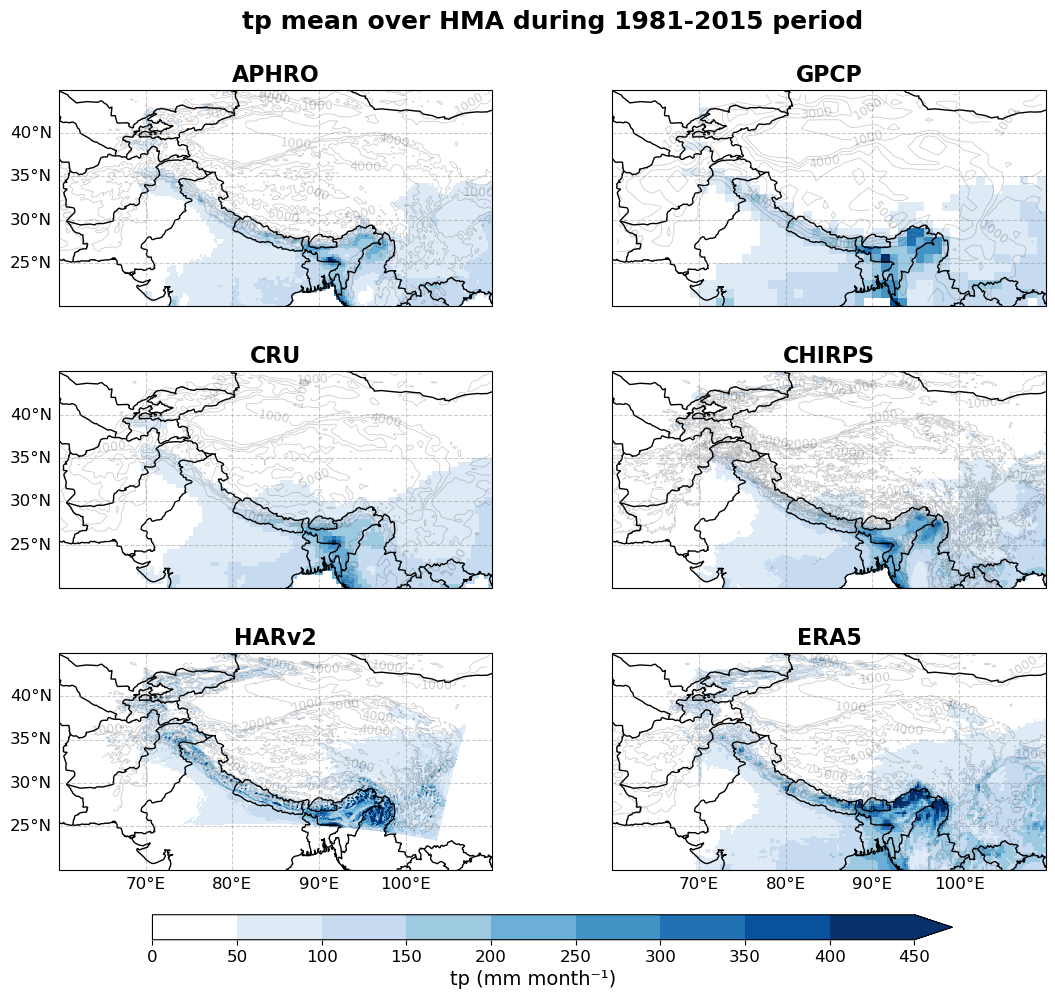

In [36]:
vmax = 500
#vmax = max(np.ceil(float(np.nanmax(np.abs(ds)))) for ds in tp_mean_dict.values())
print(vmax)
levels = np.arange(0, vmax, 50)
base_cmap = plt.get_cmap("Blues", len(levels)-1)
colors = base_cmap(np.arange(base_cmap.N))
colors[0] = [1, 1, 1, 1]  # blanc RGBA
cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(levels, ncolors=cmap.N)

fig, axes = plt.subplots(3, 2, figsize=(16, 10), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, ax in enumerate(axes):
    model = models[i]
    data_model = tp_mean_dict[model]

    im = ax.pcolormesh(data_model['lon'],data_model['lat'],data_model,transform=ccrs.PlateCarree(),cmap=cmap,norm=norm,shading="auto")

    ax.set_extent([lonW,lonE,latS,latN], crs=ccrs.PlateCarree())
    
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle="-")

    SH = ax.contour(field_SH_dict[model].lon,field_SH_dict[model].lat,field_SH_dict[model],levels=[1000,2000,3000,4000,5000,6000,7000],
                colors="k",linewidths=0.6,alpha=0.2,transform=ccrs.PlateCarree())
    ax.clabel(SH, inline=True, fontsize=9, fmt="%d")
    
    ax.set_title(model, fontsize=16, weight="bold")

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 2 == 0)
    gl.bottom_labels = (i >= 4) 
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='max')
cbar.set_label("tp (mm month⁻¹)", fontsize=14)
cbar.ax.tick_params(labelsize=12)

fig.subplots_adjust(left=0.08, right=0.92, top=0.90, bottom=0.12, wspace=-0.3, hspace=0.3)
plt.suptitle(f"tp mean over HMA during {iyear}-{fyear} period", fontsize=18, weight="bold")

plt.show()

# SEH zoom

In [34]:
latS2,latN2,lonW2,lonE2,latlim2,lonlim2 = coord_domain('SEH')

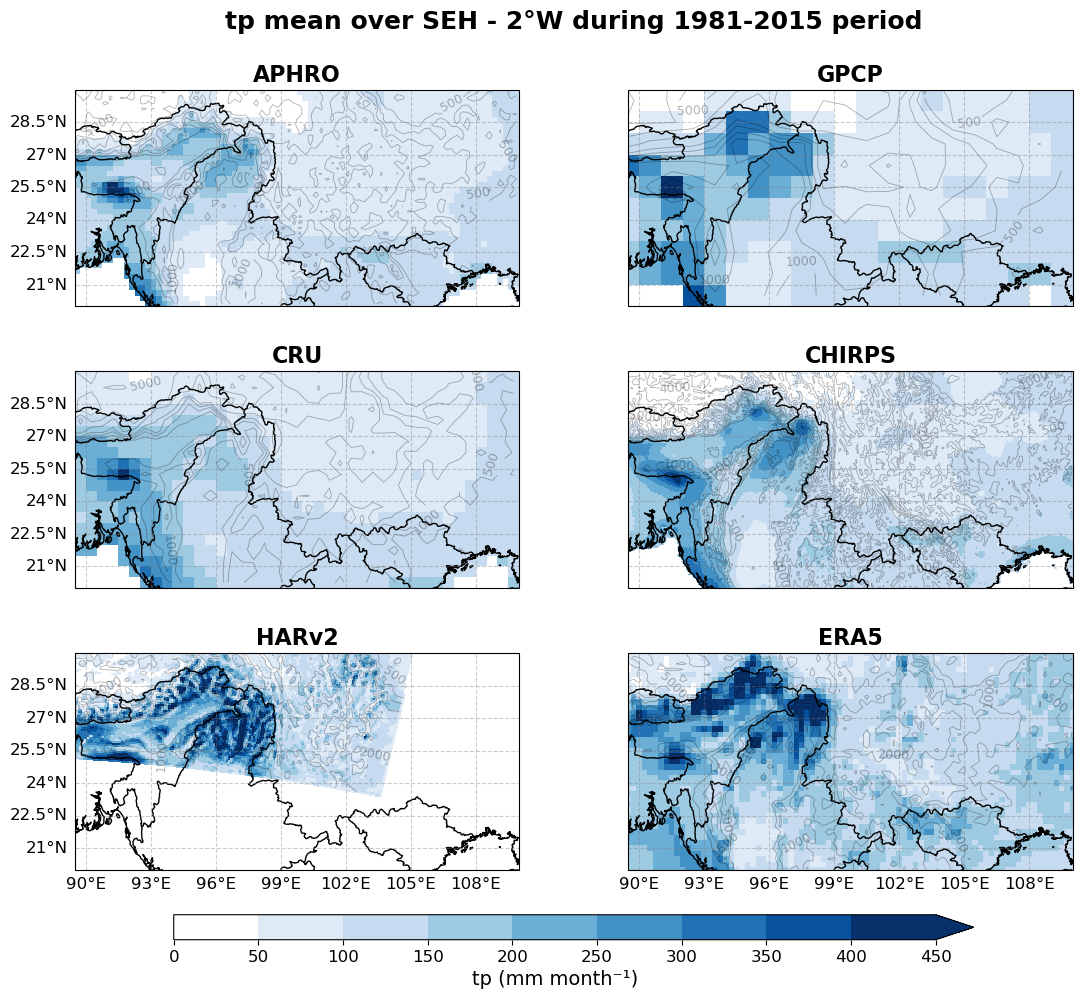

In [40]:
fig, axes = plt.subplots(3, 2, figsize=(16, 10), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, ax in enumerate(axes):
    model = models[i]
    data_model = tp_mean_dict[model]

    im = ax.pcolormesh(data_model['lon'],data_model['lat'],data_model,transform=ccrs.PlateCarree(),cmap=cmap,norm=norm,shading="auto")

    ax.set_extent([lonW2 - 2,lonE2,latS2,latN2], crs=ccrs.PlateCarree())
    
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle="-")

    SH = ax.contour(field_SH_dict[model].lon,field_SH_dict[model].lat,field_SH_dict[model],levels=[500,1000,1500,2000,3000,4000,5000,6000,7000],
                colors="k",linewidths=0.6,alpha=0.3,transform=ccrs.PlateCarree())
    ax.clabel(SH, inline=True, fontsize=9, fmt="%d")
    
    ax.set_title(model, fontsize=16, weight="bold")

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 2 == 0)
    gl.bottom_labels = (i >= 4) 
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='max')
cbar.set_label("tp (mm month⁻¹)", fontsize=14)
cbar.ax.tick_params(labelsize=12)

fig.subplots_adjust(left=0.08, right=0.92, top=0.90, bottom=0.12, wspace=-0.3, hspace=0.3)
plt.suptitle(f"tp mean over SEH - 2°W during {iyear}-{fyear} period", fontsize=18, weight="bold")

plt.show()

# Seasonal Climatology

# DJFM

In [55]:
tp_season_dict = {}
season = 'DJFM'

tp_season1 = clim(field1, season=season, imon=1, iyr=iyear, fmon=12, fyr=fyear)
tp_season_dict[models[0]] = tp_season1

tp_season2 = clim(field2, season=season, imon=1, iyr=iyear, fmon=12, fyr=fyear)
tp_season_dict[models[1]] = tp_season2

tp_season3 = clim(field3, season=season, imon=1, iyr=iyear, fmon=12, fyr=fyear)
tp_season_dict[models[2]] = tp_season3

tp_season4 = clim(field4, season=season, imon=1, iyr=iyear, fmon=12, fyr=fyear)
tp_season_dict[models[3]] = tp_season4

tp_season5 = clim(field5, season=season, imon=1, iyr=iyear, fmon=12, fyr=fyear)
tp_season_dict[models[4]] = tp_season5

tp_season6 = clim(field6, season=season, imon=1, iyr=iyear, fmon=12, fyr=fyear)
tp_season_dict[models[5]] = tp_season6

In [56]:
output_dir = '/bettik/PROJECTS/pr-regional-climate/bricej/climbas/'

for model, data in tp_season_dict.items():
    
    ds = data.to_dataset(name="tp")
    ds.attrs["units"] = "mm/month"
    ds.attrs["long_name"] = "Annual mean precipitation"
    ds.attrs["description"] = "Climatological annual mean over 1981–2015 in HMA"
    
    filename = f"{output_dir}/spatial_mean_tp_{season}_{dom}_{iyear}-{fyear}_{model}.nc"
    
    ds.to_netcdf(filename)

    print(f'Saved file : {filename}')

Saved file : /bettik/PROJECTS/pr-regional-climate/bricej/climbas//spatial_mean_tp_DJFM_HMA_1981-2015_APHRO.nc
Saved file : /bettik/PROJECTS/pr-regional-climate/bricej/climbas//spatial_mean_tp_DJFM_HMA_1981-2015_GPCP.nc
Saved file : /bettik/PROJECTS/pr-regional-climate/bricej/climbas//spatial_mean_tp_DJFM_HMA_1981-2015_CRU.nc
Saved file : /bettik/PROJECTS/pr-regional-climate/bricej/climbas//spatial_mean_tp_DJFM_HMA_1981-2015_CHIRPS.nc
Saved file : /bettik/PROJECTS/pr-regional-climate/bricej/climbas//spatial_mean_tp_DJFM_HMA_1981-2015_HARv2.nc
Saved file : /bettik/PROJECTS/pr-regional-climate/bricej/climbas//spatial_mean_tp_DJFM_HMA_1981-2015_ERA5.nc


In [37]:
season = 'DJFM'
models = ['APHRO','GPCP','CRU','CHIRPS','HARv2','ERA5']

model1='APHRO'
tp_season1 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/climbas/spatial_mean_tp_{season}_{dom}_{iyear}-{fyear}_{model1}.nc')['tp']

model2='GPCP'
tp_season2 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/climbas/spatial_mean_tp_{season}_{dom}_{iyear}-{fyear}_{model2}.nc')['tp']

model3='CRU'
tp_season3 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/climbas/spatial_mean_tp_{season}_{dom}_{iyear}-{fyear}_{model3}.nc')['tp']

model4='CHIRPS'
tp_season4 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/climbas/spatial_mean_tp_{season}_{dom}_{iyear}-{fyear}_{model4}.nc')['tp']

model5='HARv2'
tp_season5 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/climbas/spatial_mean_tp_{season}_{dom}_{iyear}-{fyear}_{model5}.nc')['tp']

model6='ERA5'
tp_season6 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/climbas/spatial_mean_tp_{season}_{dom}_{iyear}-{fyear}_{model6}.nc')['tp']

tp_season_dict = {
    models[0]: tp_season1,
    models[1]: tp_season2,
    models[2]: tp_season3,
    models[3]: tp_season4,
    models[4]: tp_season5,
    models[5]: tp_season6}

field_SH_dict = {
    models[0]: field1_SH,
    models[1]: field2_SH,
    models[2]: field3_SH,
    models[3]: field4_SH,
    models[4]: field5_SH,
    models[5]: field6_SH}

250


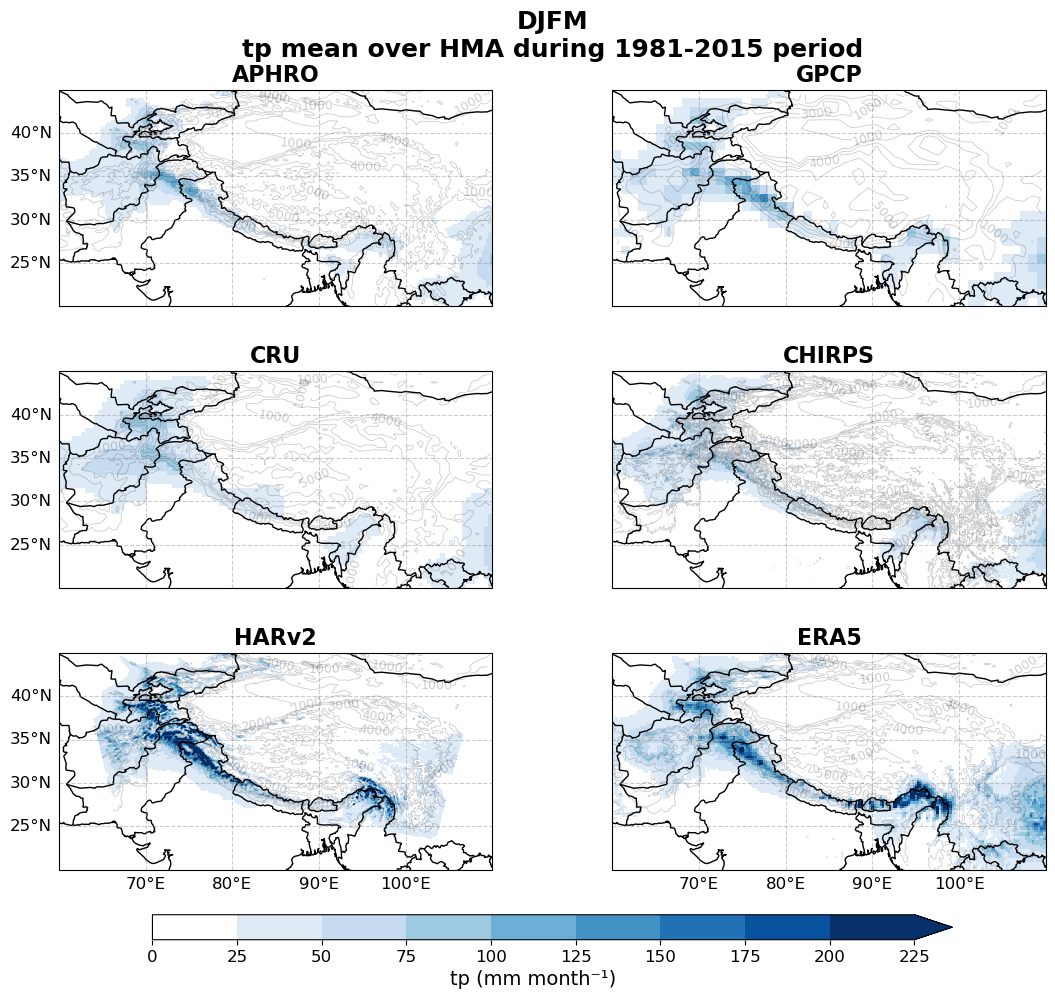

In [39]:
vmax = 250
#vmax = max(np.ceil(float(np.nanmax(np.abs(ds)))) for ds in tp_mean_dict.values())
print(vmax)
levels = np.arange(0, vmax, 25)
base_cmap = plt.get_cmap("Blues", len(levels)-1)
colors = base_cmap(np.arange(base_cmap.N))
colors[0] = [1, 1, 1, 1]  # blanc RGBA
cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(levels, ncolors=cmap.N)

fig, axes = plt.subplots(3, 2, figsize=(16, 10), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, ax in enumerate(axes):
    model = models[i]
    data_model = tp_season_dict[model]

    im = ax.pcolormesh(data_model['lon'],data_model['lat'],data_model,transform=ccrs.PlateCarree(),cmap=cmap,norm=norm,shading="auto")

    ax.set_extent([lonW,lonE,latS,latN], crs=ccrs.PlateCarree())
    
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle="-")

    SH = ax.contour(field_SH_dict[model].lon,field_SH_dict[model].lat,field_SH_dict[model],levels=[1000,2000,3000,4000,5000,6000,7000],
                colors="k",linewidths=0.6,alpha=0.2,transform=ccrs.PlateCarree())
    ax.clabel(SH, inline=True, fontsize=9, fmt="%d")
    
    ax.set_title(model, fontsize=16, weight="bold")

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 2 == 0)
    gl.bottom_labels = (i >= 4) 
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='max')
cbar.set_label("tp (mm month⁻¹)", fontsize=14)
cbar.ax.tick_params(labelsize=12)

fig.subplots_adjust(left=0.08, right=0.92, top=0.90, bottom=0.12, wspace=-0.3, hspace=0.3)
plt.suptitle(f"{season}\ntp mean over HMA during {iyear}-{fyear} period", fontsize=18, weight="bold")

plt.show()

# AM

In [57]:
tp_season_dict = {}
season = 'AM'

tp_season1 = clim(field1, season=season, imon=1, iyr=iyear, fmon=12, fyr=fyear)
tp_season_dict[models[0]] = tp_season1

tp_season2 = clim(field2, season=season, imon=1, iyr=iyear, fmon=12, fyr=fyear)
tp_season_dict[models[1]] = tp_season2

tp_season3 = clim(field3, season=season, imon=1, iyr=iyear, fmon=12, fyr=fyear)
tp_season_dict[models[2]] = tp_season3

tp_season4 = clim(field4, season=season, imon=1, iyr=iyear, fmon=12, fyr=fyear)
tp_season_dict[models[3]] = tp_season4

tp_season5 = clim(field5, season=season, imon=1, iyr=iyear, fmon=12, fyr=fyear)
tp_season_dict[models[4]] = tp_season5

tp_season6 = clim(field6, season=season, imon=1, iyr=iyear, fmon=12, fyr=fyear)
tp_season_dict[models[5]] = tp_season6

In [58]:
output_dir = '/bettik/PROJECTS/pr-regional-climate/bricej/climbas/'

for model, data in tp_season_dict.items():
    
    ds = data.to_dataset(name="tp")
    ds.attrs["units"] = "mm/month"
    ds.attrs["long_name"] = "Annual mean precipitation"
    ds.attrs["description"] = "Climatological annual mean over 1981–2015 in HMA"
    
    filename = f"{output_dir}/spatial_mean_tp_{season}_{dom}_{iyear}-{fyear}_{model}.nc"
    
    ds.to_netcdf(filename)

    print(f'Saved file : {filename}')

Saved file : /bettik/PROJECTS/pr-regional-climate/bricej/climbas//spatial_mean_tp_AM_HMA_1981-2015_APHRO.nc
Saved file : /bettik/PROJECTS/pr-regional-climate/bricej/climbas//spatial_mean_tp_AM_HMA_1981-2015_GPCP.nc
Saved file : /bettik/PROJECTS/pr-regional-climate/bricej/climbas//spatial_mean_tp_AM_HMA_1981-2015_CRU.nc
Saved file : /bettik/PROJECTS/pr-regional-climate/bricej/climbas//spatial_mean_tp_AM_HMA_1981-2015_CHIRPS.nc
Saved file : /bettik/PROJECTS/pr-regional-climate/bricej/climbas//spatial_mean_tp_AM_HMA_1981-2015_HARv2.nc
Saved file : /bettik/PROJECTS/pr-regional-climate/bricej/climbas//spatial_mean_tp_AM_HMA_1981-2015_ERA5.nc


In [40]:
season = 'AM'
models = ['APHRO','GPCP','CRU','CHIRPS','HARv2','ERA5']

model1='APHRO'
tp_season1 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/climbas/spatial_mean_tp_{season}_{dom}_{iyear}-{fyear}_{model1}.nc')['tp']

model2='GPCP'
tp_season2 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/climbas/spatial_mean_tp_{season}_{dom}_{iyear}-{fyear}_{model2}.nc')['tp']

model3='CRU'
tp_season3 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/climbas/spatial_mean_tp_{season}_{dom}_{iyear}-{fyear}_{model3}.nc')['tp']

model4='CHIRPS'
tp_season4 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/climbas/spatial_mean_tp_{season}_{dom}_{iyear}-{fyear}_{model4}.nc')['tp']

model5='HARv2'
tp_season5 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/climbas/spatial_mean_tp_{season}_{dom}_{iyear}-{fyear}_{model5}.nc')['tp']

model6='ERA5'
tp_season6 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/climbas/spatial_mean_tp_{season}_{dom}_{iyear}-{fyear}_{model6}.nc')['tp']

tp_season_dict = {
    models[0]: tp_season1,
    models[1]: tp_season2,
    models[2]: tp_season3,
    models[3]: tp_season4,
    models[4]: tp_season5,
    models[5]: tp_season6}

field_SH_dict = {
    models[0]: field1_SH,
    models[1]: field2_SH,
    models[2]: field3_SH,
    models[3]: field4_SH,
    models[4]: field5_SH,
    models[5]: field6_SH}

500


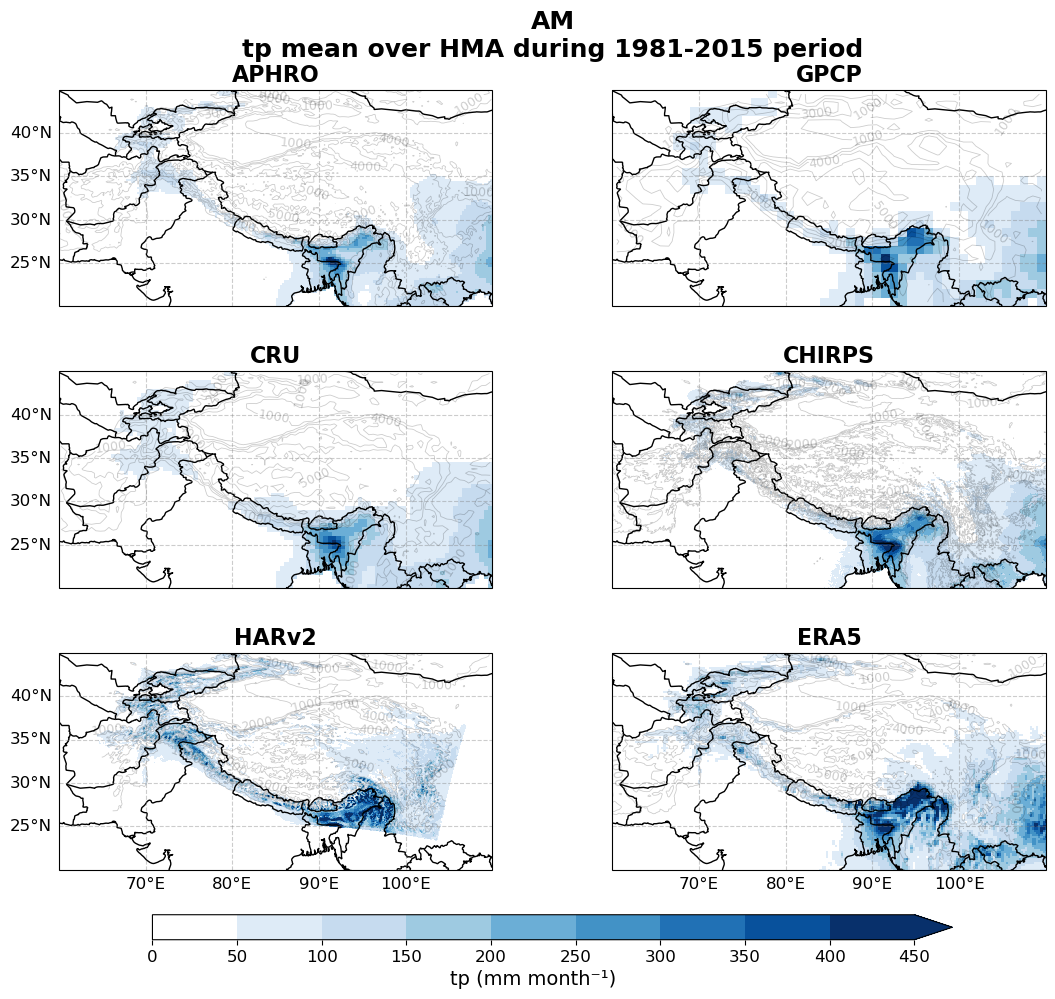

In [43]:
vmax = 500
#vmax = max(np.ceil(float(np.nanmax(np.abs(ds)))) for ds in tp_mean_dict.values())
print(vmax)
levels = np.arange(0, vmax, 50)
base_cmap = plt.get_cmap("Blues", len(levels)-1)
colors = base_cmap(np.arange(base_cmap.N))
colors[0] = [1, 1, 1, 1]  # blanc RGBA
cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(levels, ncolors=cmap.N)

fig, axes = plt.subplots(3, 2, figsize=(16, 10), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, ax in enumerate(axes):
    model = models[i]
    data_model = tp_season_dict[model]

    im = ax.pcolormesh(data_model['lon'],data_model['lat'],data_model,transform=ccrs.PlateCarree(),cmap=cmap,norm=norm,shading="auto")

    ax.set_extent([lonW,lonE,latS,latN], crs=ccrs.PlateCarree())
    
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle="-")

    SH = ax.contour(field_SH_dict[model].lon,field_SH_dict[model].lat,field_SH_dict[model],levels=[1000,2000,3000,4000,5000,6000,7000],
                colors="k",linewidths=0.6,alpha=0.2,transform=ccrs.PlateCarree())
    ax.clabel(SH, inline=True, fontsize=9, fmt="%d")
    
    ax.set_title(model, fontsize=16, weight="bold")

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 2 == 0)
    gl.bottom_labels = (i >= 4) 
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='max')
cbar.set_label("tp (mm month⁻¹)", fontsize=14)
cbar.ax.tick_params(labelsize=12)

fig.subplots_adjust(left=0.08, right=0.92, top=0.90, bottom=0.12, wspace=-0.3, hspace=0.3)
plt.suptitle(f"{season}\ntp mean over HMA during {iyear}-{fyear} period", fontsize=18, weight="bold")

plt.show()

# JJAS

In [59]:
tp_season_dict = {}
season = 'JJAS'

tp_season1 = clim(field1, season=season, imon=1, iyr=iyear, fmon=12, fyr=fyear)
tp_season_dict[models[0]] = tp_season1

tp_season2 = clim(field2, season=season, imon=1, iyr=iyear, fmon=12, fyr=fyear)
tp_season_dict[models[1]] = tp_season2

tp_season3 = clim(field3, season=season, imon=1, iyr=iyear, fmon=12, fyr=fyear)
tp_season_dict[models[2]] = tp_season3

tp_season4 = clim(field4, season=season, imon=1, iyr=iyear, fmon=12, fyr=fyear)
tp_season_dict[models[3]] = tp_season4

tp_season5 = clim(field5, season=season, imon=1, iyr=iyear, fmon=12, fyr=fyear)
tp_season_dict[models[4]] = tp_season5

tp_season6 = clim(field6, season=season, imon=1, iyr=iyear, fmon=12, fyr=fyear)
tp_season_dict[models[5]] = tp_season6

In [60]:
output_dir = '/bettik/PROJECTS/pr-regional-climate/bricej/climbas/'

for model, data in tp_season_dict.items():
    
    ds = data.to_dataset(name="tp")
    ds.attrs["units"] = "mm/month"
    ds.attrs["long_name"] = "Annual mean precipitation"
    ds.attrs["description"] = "Climatological annual mean over 1981–2015 in HMA"
    
    filename = f"{output_dir}/spatial_mean_tp_{season}_{dom}_{iyear}-{fyear}_{model}.nc"
    
    ds.to_netcdf(filename)

    print(f'Saved file : {filename}')

Saved file : /bettik/PROJECTS/pr-regional-climate/bricej/climbas//spatial_mean_tp_JJAS_HMA_1981-2015_APHRO.nc
Saved file : /bettik/PROJECTS/pr-regional-climate/bricej/climbas//spatial_mean_tp_JJAS_HMA_1981-2015_GPCP.nc
Saved file : /bettik/PROJECTS/pr-regional-climate/bricej/climbas//spatial_mean_tp_JJAS_HMA_1981-2015_CRU.nc
Saved file : /bettik/PROJECTS/pr-regional-climate/bricej/climbas//spatial_mean_tp_JJAS_HMA_1981-2015_CHIRPS.nc
Saved file : /bettik/PROJECTS/pr-regional-climate/bricej/climbas//spatial_mean_tp_JJAS_HMA_1981-2015_HARv2.nc
Saved file : /bettik/PROJECTS/pr-regional-climate/bricej/climbas//spatial_mean_tp_JJAS_HMA_1981-2015_ERA5.nc


In [44]:
season = 'JJAS'
models = ['APHRO','GPCP','CRU','CHIRPS','HARv2','ERA5']

model1='APHRO'
tp_season1 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/climbas/spatial_mean_tp_{season}_{dom}_{iyear}-{fyear}_{model1}.nc')['tp']

model2='GPCP'
tp_season2 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/climbas/spatial_mean_tp_{season}_{dom}_{iyear}-{fyear}_{model2}.nc')['tp']

model3='CRU'
tp_season3 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/climbas/spatial_mean_tp_{season}_{dom}_{iyear}-{fyear}_{model3}.nc')['tp']

model4='CHIRPS'
tp_season4 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/climbas/spatial_mean_tp_{season}_{dom}_{iyear}-{fyear}_{model4}.nc')['tp']

model5='HARv2'
tp_season5 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/climbas/spatial_mean_tp_{season}_{dom}_{iyear}-{fyear}_{model5}.nc')['tp']

model6='ERA5'
tp_season6 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/climbas/spatial_mean_tp_{season}_{dom}_{iyear}-{fyear}_{model6}.nc')['tp']

tp_season_dict = {
    models[0]: tp_season1,
    models[1]: tp_season2,
    models[2]: tp_season3,
    models[3]: tp_season4,
    models[4]: tp_season5,
    models[5]: tp_season6}

field_SH_dict = {
    models[0]: field1_SH,
    models[1]: field2_SH,
    models[2]: field3_SH,
    models[3]: field4_SH,
    models[4]: field5_SH,
    models[5]: field6_SH}

900


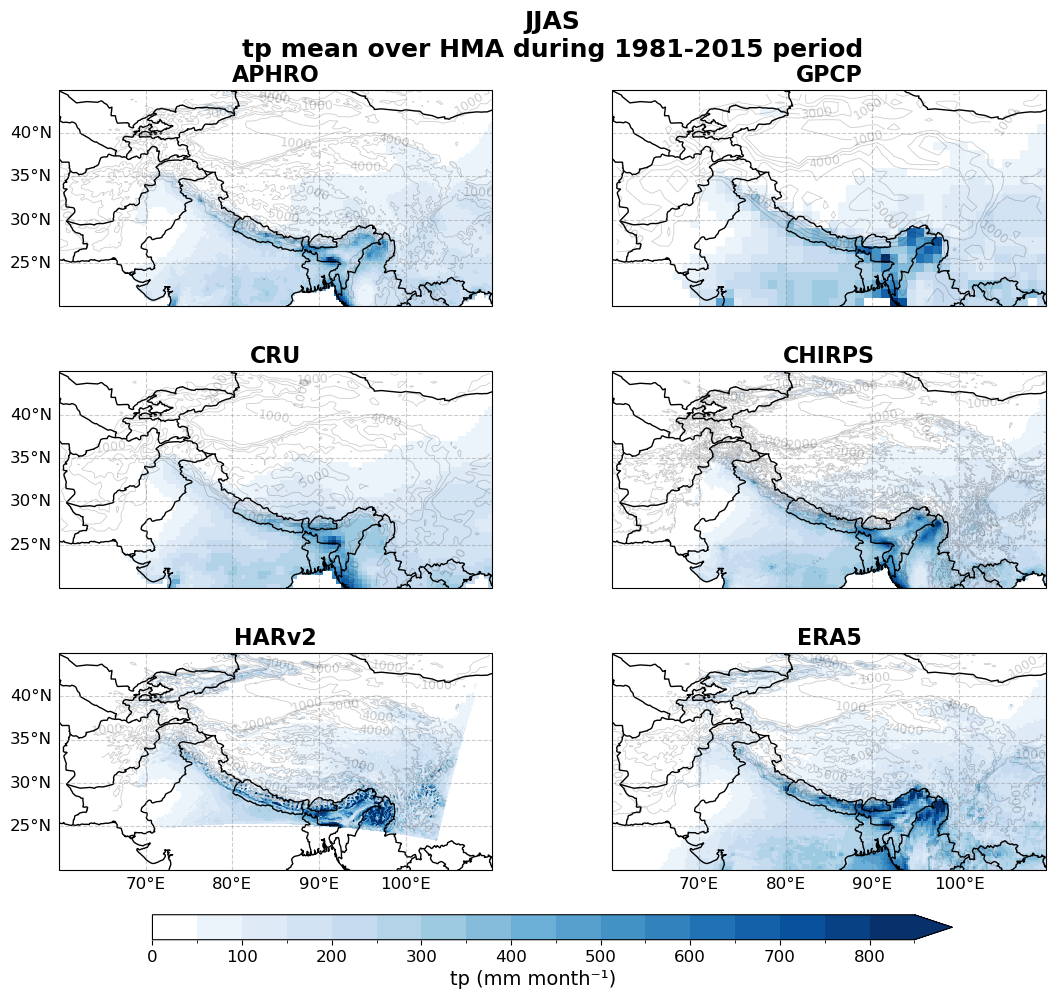

In [45]:
vmax = 900
#vmax = max(np.ceil(float(np.nanmax(np.abs(ds)))) for ds in tp_mean_dict.values())
print(vmax)
levels = np.arange(0, vmax, 50)
base_cmap = plt.get_cmap("Blues", len(levels)-1)
colors = base_cmap(np.arange(base_cmap.N))
colors[0] = [1, 1, 1, 1]  # blanc RGBA
cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(levels, ncolors=cmap.N)

fig, axes = plt.subplots(3, 2, figsize=(16, 10), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, ax in enumerate(axes):
    model = models[i]
    data_model = tp_season_dict[model]

    im = ax.pcolormesh(data_model['lon'],data_model['lat'],data_model,transform=ccrs.PlateCarree(),cmap=cmap,norm=norm,shading="auto")

    ax.set_extent([lonW,lonE,latS,latN], crs=ccrs.PlateCarree())
    
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle="-")

    SH = ax.contour(field_SH_dict[model].lon,field_SH_dict[model].lat,field_SH_dict[model],levels=[1000,2000,3000,4000,5000,6000,7000],
                colors="k",linewidths=0.6,alpha=0.2,transform=ccrs.PlateCarree())
    ax.clabel(SH, inline=True, fontsize=9, fmt="%d")
    
    ax.set_title(model, fontsize=16, weight="bold")

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 2 == 0)
    gl.bottom_labels = (i >= 4) 
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='max')
cbar.set_label("tp (mm month⁻¹)", fontsize=14)
cbar.ax.tick_params(labelsize=12)

fig.subplots_adjust(left=0.08, right=0.92, top=0.90, bottom=0.12, wspace=-0.3, hspace=0.3)
plt.suptitle(f"{season}\ntp mean over HMA during {iyear}-{fyear} period", fontsize=18, weight="bold")

plt.show()

# ON

In [61]:
tp_season_dict = {}
season = 'ON'

tp_season1 = clim(field1, season=season, imon=1, iyr=iyear, fmon=12, fyr=fyear)
tp_season_dict[models[0]] = tp_season1

tp_season2 = clim(field2, season=season, imon=1, iyr=iyear, fmon=12, fyr=fyear)
tp_season_dict[models[1]] = tp_season2

tp_season3 = clim(field3, season=season, imon=1, iyr=iyear, fmon=12, fyr=fyear)
tp_season_dict[models[2]] = tp_season3

tp_season4 = clim(field4, season=season, imon=1, iyr=iyear, fmon=12, fyr=fyear)
tp_season_dict[models[3]] = tp_season4

tp_season5 = clim(field5, season=season, imon=1, iyr=iyear, fmon=12, fyr=fyear)
tp_season_dict[models[4]] = tp_season5

tp_season6 = clim(field6, season=season, imon=1, iyr=iyear, fmon=12, fyr=fyear)
tp_season_dict[models[5]] = tp_season6

In [62]:
output_dir = '/bettik/PROJECTS/pr-regional-climate/bricej/climbas/'

for model, data in tp_season_dict.items():
    
    ds = data.to_dataset(name="tp")
    ds.attrs["units"] = "mm/month"
    ds.attrs["long_name"] = "Annual mean precipitation"
    ds.attrs["description"] = "Climatological annual mean over 1981–2015 in HMA"
    
    filename = f"{output_dir}/spatial_mean_tp_{season}_{dom}_{iyear}-{fyear}_{model}.nc"
    
    ds.to_netcdf(filename)

    print(f'Saved file : {filename}')

Saved file : /bettik/PROJECTS/pr-regional-climate/bricej/climbas//spatial_mean_tp_ON_HMA_1981-2015_APHRO.nc
Saved file : /bettik/PROJECTS/pr-regional-climate/bricej/climbas//spatial_mean_tp_ON_HMA_1981-2015_GPCP.nc
Saved file : /bettik/PROJECTS/pr-regional-climate/bricej/climbas//spatial_mean_tp_ON_HMA_1981-2015_CRU.nc
Saved file : /bettik/PROJECTS/pr-regional-climate/bricej/climbas//spatial_mean_tp_ON_HMA_1981-2015_CHIRPS.nc
Saved file : /bettik/PROJECTS/pr-regional-climate/bricej/climbas//spatial_mean_tp_ON_HMA_1981-2015_HARv2.nc
Saved file : /bettik/PROJECTS/pr-regional-climate/bricej/climbas//spatial_mean_tp_ON_HMA_1981-2015_ERA5.nc


In [46]:
season = 'ON'
models = ['APHRO','GPCP','CRU','CHIRPS','HARv2','ERA5']

model1='APHRO'
tp_season1 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/climbas/spatial_mean_tp_{season}_{dom}_{iyear}-{fyear}_{model1}.nc')['tp']

model2='GPCP'
tp_season2 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/climbas/spatial_mean_tp_{season}_{dom}_{iyear}-{fyear}_{model2}.nc')['tp']

model3='CRU'
tp_season3 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/climbas/spatial_mean_tp_{season}_{dom}_{iyear}-{fyear}_{model3}.nc')['tp']

model4='CHIRPS'
tp_season4 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/climbas/spatial_mean_tp_{season}_{dom}_{iyear}-{fyear}_{model4}.nc')['tp']

model5='HARv2'
tp_season5 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/climbas/spatial_mean_tp_{season}_{dom}_{iyear}-{fyear}_{model5}.nc')['tp']

model6='ERA5'
tp_season6 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/climbas/spatial_mean_tp_{season}_{dom}_{iyear}-{fyear}_{model6}.nc')['tp']

tp_season_dict = {
    models[0]: tp_season1,
    models[1]: tp_season2,
    models[2]: tp_season3,
    models[3]: tp_season4,
    models[4]: tp_season5,
    models[5]: tp_season6}

field_SH_dict = {
    models[0]: field1_SH,
    models[1]: field2_SH,
    models[2]: field3_SH,
    models[3]: field4_SH,
    models[4]: field5_SH,
    models[5]: field6_SH}

275


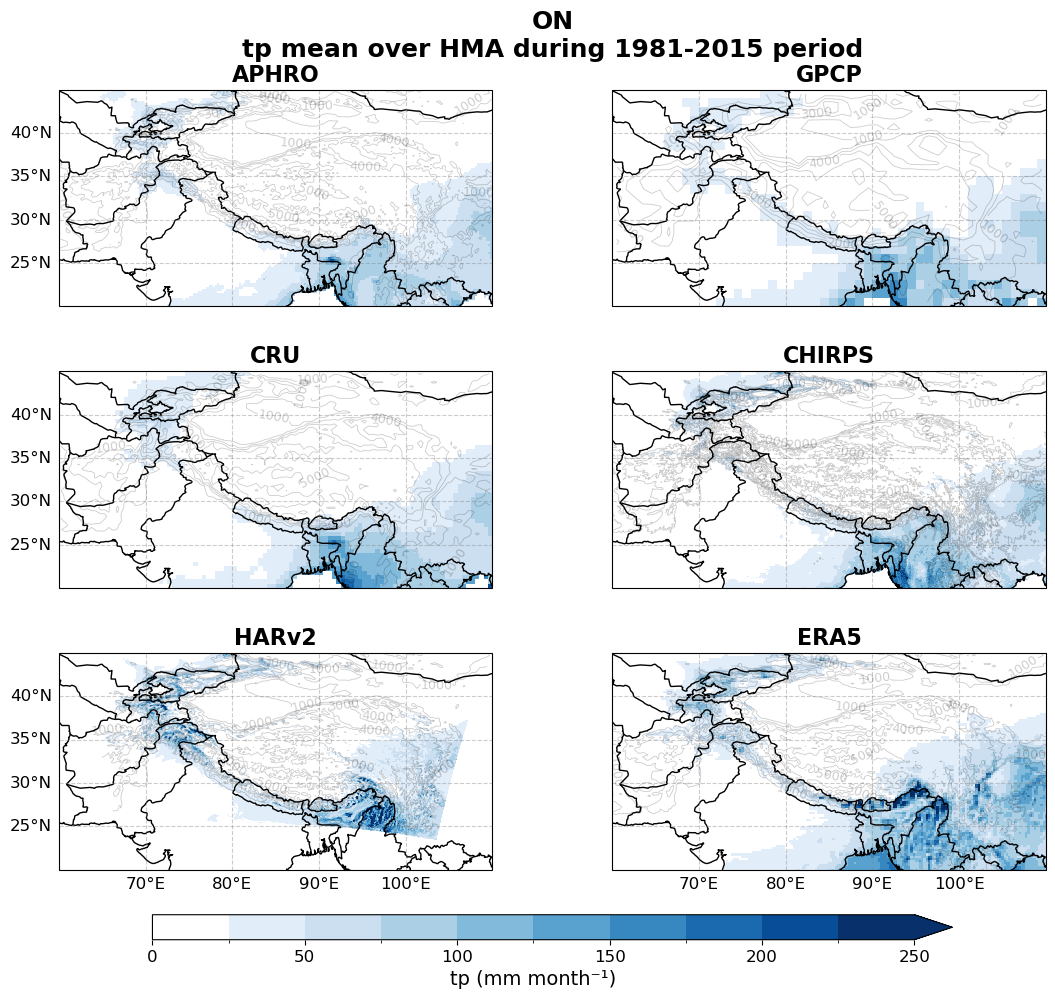

In [47]:
vmax = 275
#vmax = max(np.ceil(float(np.nanmax(np.abs(ds)))) for ds in tp_mean_dict.values())
print(vmax)
levels = np.arange(0, vmax, 25)
base_cmap = plt.get_cmap("Blues", len(levels)-1)
colors = base_cmap(np.arange(base_cmap.N))
colors[0] = [1, 1, 1, 1]  # blanc RGBA
cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(levels, ncolors=cmap.N)

fig, axes = plt.subplots(3, 2, figsize=(16, 10), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, ax in enumerate(axes):
    model = models[i]
    data_model = tp_season_dict[model]

    im = ax.pcolormesh(data_model['lon'],data_model['lat'],data_model,transform=ccrs.PlateCarree(),cmap=cmap,norm=norm,shading="auto")

    ax.set_extent([lonW,lonE,latS,latN], crs=ccrs.PlateCarree())
    
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle="-")

    SH = ax.contour(field_SH_dict[model].lon,field_SH_dict[model].lat,field_SH_dict[model],levels=[1000,2000,3000,4000,5000,6000,7000],
                colors="k",linewidths=0.6,alpha=0.2,transform=ccrs.PlateCarree())
    ax.clabel(SH, inline=True, fontsize=9, fmt="%d")
    
    ax.set_title(model, fontsize=16, weight="bold")

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 2 == 0)
    gl.bottom_labels = (i >= 4) 
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='max')
cbar.set_label("tp (mm month⁻¹)", fontsize=14)
cbar.ax.tick_params(labelsize=12)

fig.subplots_adjust(left=0.08, right=0.92, top=0.90, bottom=0.12, wspace=-0.3, hspace=0.3)
plt.suptitle(f"{season}\ntp mean over HMA during {iyear}-{fyear} period", fontsize=18, weight="bold")

plt.show()

# Annual Trend

In [17]:
trend_annual_dict={}
p_annual_dict={}
season='annual'

In [17]:
tp_annual1,_ = seasonal_selection(field1, 'JFMAMJJASOND', iyear, fyear)
par1 = trend_vect(tp_annual1.time,tp_annual1,dim='time')
trend1 = par1[0];p1 = par1[3]
trend_annual_dict[models[0]] = trend1
p_annual_dict[models[0]] = p1

5


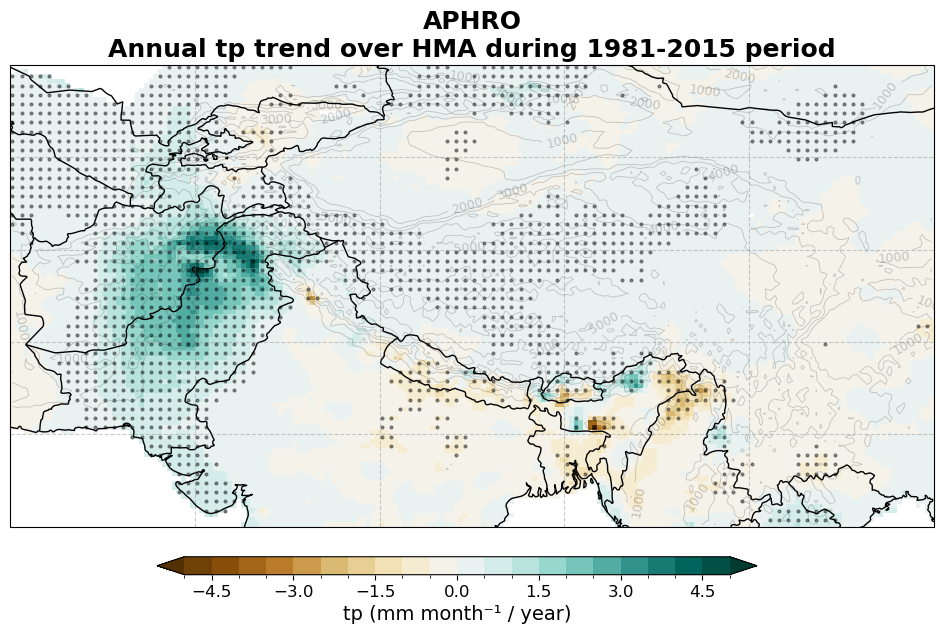

In [40]:
step = 0.5
vmax = 5
#vmax = max(np.round(float(np.nanmax(np.abs(ds))), 1) for ds in trend_annual_dict.values())
print(vmax)
levels = np.linspace(-vmax, vmax, int(2*vmax/step)+1)
cmap = plt.get_cmap("BrBG", len(levels)-1+2)
norm = mcolors.BoundaryNorm(levels, ncolors=cmap.N, extend='both')

fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12,6))

model = models[0]
data_model = trend_annual_dict[model]

pcm = ax.pcolormesh(data_model['lon'],data_model['lat'],data_model,transform=ccrs.PlateCarree(),cmap=cmap,norm=norm,shading="auto")

sig = p_annual_dict[model] < 0.05 
step = 2
lon_sig, lat_sig = data_model['lon'].values, data_model['lat'].values
lon_grid, lat_grid = np.meshgrid(lon_sig, lat_sig)
ax.scatter(lon_grid[::step, ::step][np.where(sig[::step, ::step])],lat_grid[::step, ::step][np.where(sig[::step, ::step])],
           color='black', s=4, marker='o', transform=ccrs.PlateCarree(), zorder=5, alpha=0.4)
    
ax.set_extent([lonW,lonE,latS,latN], crs=ccrs.PlateCarree())
    
ax.add_feature(cfeature.COASTLINE, linewidth=1)
ax.add_feature(cfeature.BORDERS, linestyle="-")

SH = ax.contour(field_SH_dict[model].lon,field_SH_dict[model].lat,field_SH_dict[model],levels=[1000,2000,3000,4000,5000,6000,7000],
                colors="k",linewidths=0.6,alpha=0.2,transform=ccrs.PlateCarree())
ax.clabel(SH, inline=True, fontsize=9, fmt="%d")
    
ax.set_title(model, fontsize=16, weight="bold")

gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
gl.top_labels = False
gl.right_labels = False
gl.left_labels = (i % 2 == 0)
gl.bottom_labels = (i >= 4) 
gl.xlabel_style = {"size": 12}
gl.ylabel_style = {"size": 12}

cbar_ax = fig.add_axes([0.25, 0.03, 0.5, 0.03])
cbar = fig.colorbar(pcm, cax=cbar_ax, orientation="horizontal", extend='both')
cbar.set_label("tp (mm month⁻¹ / year)", fontsize=14)
cbar.ax.tick_params(labelsize=12)

ax.set_title(f"APHRO\nAnnual tp trend over HMA during {iyear}-{fyear} period", fontsize=18, weight="bold")

plt.show()

In [48]:
output_dir = '/bettik/PROJECTS/pr-regional-climate/bricej/climbas/'

var_names = ['trend', 'intercept', 'rvalue', 'pvalue', 'stderr']
ds = xr.Dataset({name: da for name, da in zip(var_names, par1)})
ds.attrs["description"] = "tp annual linregress over 1981–2015 in HMA"
    
filename = f"{output_dir}/spatial_trend_tp_annual_{dom}_{iyear}-{fyear}_APHRO.nc"
    
ds.to_netcdf(filename)

print(f'Saved file : {filename}')

Saved file : /bettik/PROJECTS/pr-regional-climate/bricej/climbas//spatial_trend_tp_annual_HMA_1981-2015_APHRO.nc


In [49]:
tp_annual2,_ = seasonal_selection(field2, 'JFMAMJJASOND', iyear, fyear)
par2 = trend_vect(tp_annual2.time,tp_annual2,dim='time')
trend2 = par2[0];p2 = par2[3]
trend_annual_dict[models[1]] = trend2
p_annual_dict[models[1]] = p2

In [53]:
output_dir = '/bettik/PROJECTS/pr-regional-climate/bricej/climbas/'

var_names = ['trend', 'intercept', 'rvalue', 'pvalue', 'stderr']
ds = xr.Dataset({name: da for name, da in zip(var_names, par2)})
ds.attrs["description"] = "tp annual linregress over 1981–2015 in HMA"
    
filename = f"{output_dir}/spatial_trend_tp_annual_{dom}_{iyear}-{fyear}_GPCP.nc"
    
ds.to_netcdf(filename)

print(f'Saved file : {filename}')

Saved file : /bettik/PROJECTS/pr-regional-climate/bricej/climbas//spatial_trend_tp_annual_HMA_1981-2015_GPCP.nc


In [54]:
tp_annual3,_ = seasonal_selection(field3, 'JFMAMJJASOND', iyear, fyear)
par3 = trend_vect(tp_annual3.time,tp_annual3,dim='time')
trend3 = par3[0];p3 = par3[3]
trend_annual_dict[models[2]] = trend1
p_annual_dict[models[2]] = p3

In [60]:
output_dir = '/bettik/PROJECTS/pr-regional-climate/bricej/climbas/'

var_names = ['trend', 'intercept', 'rvalue', 'pvalue', 'stderr']
ds = xr.Dataset({name: da for name, da in zip(var_names, par3)})
ds.attrs["description"] = "tp annual linregress over 1981–2015 in HMA"
    
filename = f"{output_dir}/spatial_trend_tp_annual_{dom}_{iyear}-{fyear}_CRU.nc"
    
ds.to_netcdf(filename)

print(f'Saved file : {filename}')

Saved file : /bettik/PROJECTS/pr-regional-climate/bricej/climbas//spatial_trend_tp_annual_HMA_1981-2015_CRU.nc


In [ ]:
#tp_annual4,_ = seasonal_selection(field4, 'JFMAMJJASOND', iyear, fyear)
#par4 = trend_vect(tp_annual4.time,tp_annual4,dim='time')
#trend4 = par4[0];p4 = par4[3]
#trend_annual_dict[models[3]] = trend4
#p_annual_dict[models[3]] = p4

In [25]:
#field4 = field4.chunk({"time": 12})
#tp_annual4,_ = seasonal_selection_chunk(field4, season, iyear, fyear)
#tp_annual4=tp_annual4.compute()
#par4 = trend_vect(tp_annual4.time,tp_annual4,dim='time')
#trend4 = par4[0];p4 = par4[3]
#trend_annual_dict[models[3]] = trend4
#p_annual_dict[models[3]] = p4

In [18]:
tp_annual5,_ = seasonal_selection(field5, 'JFMAMJJASOND', iyear, fyear)
tp_annual5 = tp_annual5.assign_coords(
    lat = field5.lat,
    lon = field5.lon
)
par5 = trend_vect(tp_annual5.time,tp_annual5,dim='time')
trend5 = par5[0];p5 = par5[3]
trend_annual_dict[models[4]] = trend5
p_annual_dict[models[4]] = p5

In [22]:
output_dir = '/bettik/PROJECTS/pr-regional-climate/bricej/climbas/'

var_names = ['trend', 'intercept', 'rvalue', 'pvalue', 'stderr']
ds = xr.Dataset({name: da for name, da in zip(var_names, par5)})
ds.attrs["description"] = "tp annual linregress over 1981–2015 in HMA"
    
filename = f"{output_dir}/spatial_trend_tp_annual_{dom}_{iyear}-{fyear}_HARv2.nc"
    
ds.to_netcdf(filename)

print(f'Saved file : {filename}')

Saved file : /bettik/PROJECTS/pr-regional-climate/bricej/climbas//spatial_trend_tp_annual_HMA_1981-2015_HARv2.nc


In [61]:
tp_annual6,_ = seasonal_selection(field6, 'JFMAMJJASOND', iyear, fyear)
par6 = trend_vect(tp_annual6.time,tp_annual6,dim='time')
trend6 = par6[0];p6 = par6[3]
trend_annual_dict[models[5]] = trend6
p_annual_dict[models[5]] = p6

In [63]:
output_dir = '/bettik/PROJECTS/pr-regional-climate/bricej/climbas/'

var_names = ['trend', 'intercept', 'rvalue', 'pvalue', 'stderr']
ds = xr.Dataset({name: da for name, da in zip(var_names, par6)})
ds.attrs["description"] = "tp annual linregress over 1981–2015 in HMA"
    
filename = f"{output_dir}/spatial_trend_tp_annual_{dom}_{iyear}-{fyear}_ERA5.nc"
    
ds.to_netcdf(filename)

print(f'Saved file : {filename}')

Saved file : /bettik/PROJECTS/pr-regional-climate/bricej/climbas//spatial_trend_tp_annual_HMA_1981-2015_ERA5.nc


In [29]:
trend_annual_dict={}
p_annual_dict={}

models = ['APHRO','GPCP','CRU','HARv2','ERA5']

model1='APHRO'
par1 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/climbas/spatial_trend_tp_annual_{dom}_{iyear}-{fyear}_{model1}.nc')
trend1 = par1['trend'];p1 = par1['pvalue']
trend_annual_dict[models[0]] = trend1
p_annual_dict[models[0]] = p1

model2='GPCP'
par2 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/climbas/spatial_trend_tp_annual_{dom}_{iyear}-{fyear}_{model2}.nc')
trend2 = par2['trend'];p2 = par2['pvalue']
trend_annual_dict[models[1]] = trend2
p_annual_dict[models[1]] = p2

model3='CRU'
par3 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/climbas/spatial_trend_tp_annual_{dom}_{iyear}-{fyear}_{model3}.nc')
trend3 = par3['trend'];p3 = par3['pvalue']
trend_annual_dict[models[2]] = trend3
p_annual_dict[models[2]] = p3

model4='HARv2'
par4 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/climbas/spatial_trend_tp_annual_{dom}_{iyear}-{fyear}_{model4}.nc')
trend4 = par4['trend'];p4 = par4['pvalue']
trend_annual_dict[models[3]] = trend4
p_annual_dict[models[3]] = p4

model5='ERA5'
par5 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/climbas/spatial_trend_tp_annual_{dom}_{iyear}-{fyear}_{model5}.nc')
trend5 = par5['trend'];p5 = par5['pvalue']
trend_annual_dict[models[4]] = trend5
p_annual_dict[models[4]] = p5

5


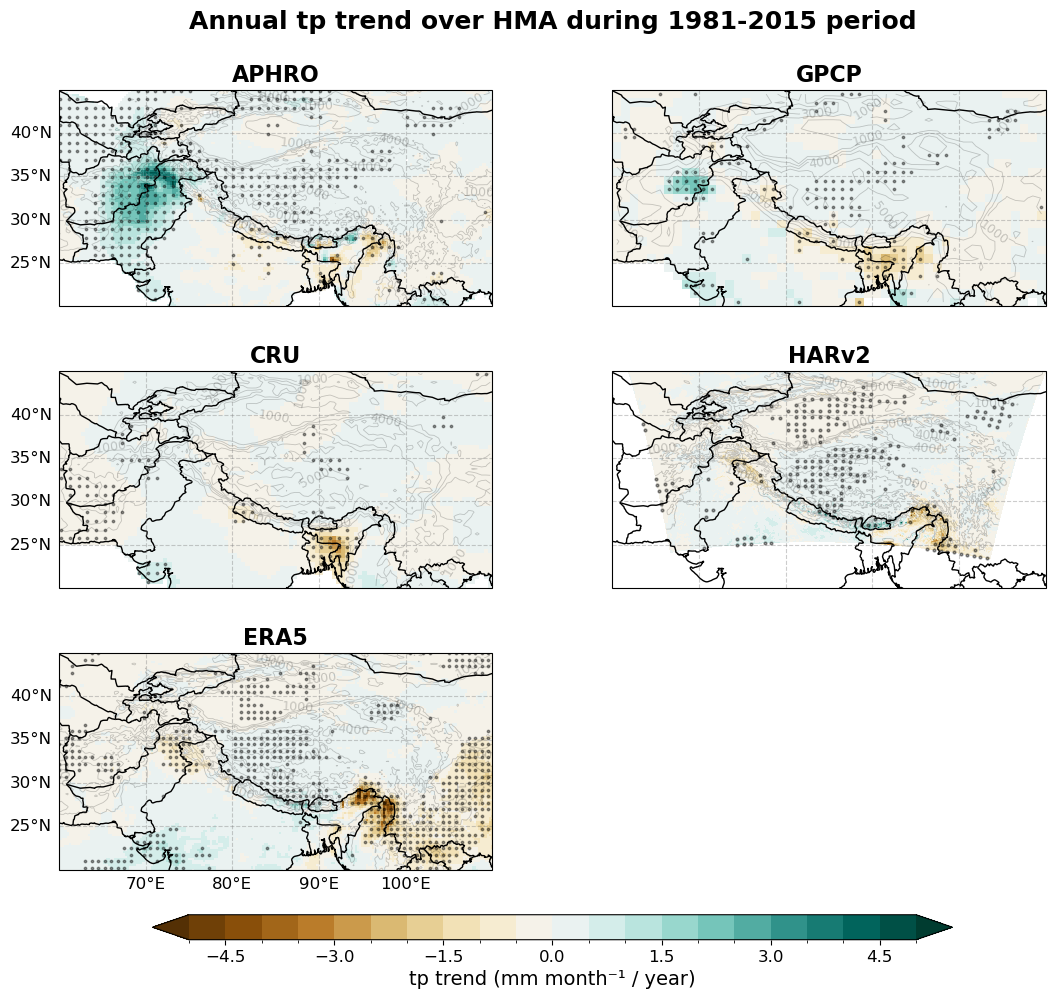

In [34]:
step_p = {
    models[0]: 4,
    models[1]: 1,
    models[2]: 2,
    models[3]: 8,
    models[4]: 3}

step = 0.5
vmax = 5
#vmax = max(np.round(float(np.nanmax(np.abs(ds))), 1) for ds in trend_annual_dict.values())
print(vmax)
levels = np.linspace(-vmax, vmax, int(2*vmax/step)+1)
cmap = plt.get_cmap("BrBG", len(levels)-1+2)
norm = mcolors.BoundaryNorm(levels, ncolors=cmap.N, extend='both')

fig, axes = plt.subplots(3, 2, figsize=(16, 10), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, (ax, model) in enumerate(zip(axes, models)):
    #model = models[i]
    data_model = trend_annual_dict[model]

    im = ax.pcolormesh(data_model['lon'],data_model['lat'],data_model,transform=ccrs.PlateCarree(),cmap=cmap,norm=norm,shading="auto")

    sig = p_annual_dict[model] < 0.05 
    step = step_p[model]
    if model == 'HARv2':
        lon2d = data_model['lon'].values
        lat2d = data_model['lat'].values
        mask = sig.values
        ax.scatter(lon2d[::step, ::step][mask[::step, ::step]],lat2d[::step, ::step][mask[::step, ::step]],
                    color='black',s=4,marker='o',transform=ccrs.PlateCarree(),zorder=5,alpha=0.4)
    else:
        lon_sig, lat_sig = data_model['lon'].values, data_model['lat'].values
        lon_grid, lat_grid = np.meshgrid(lon_sig, lat_sig)
        ax.scatter(lon_grid[::step, ::step][np.where(sig[::step, ::step])],lat_grid[::step, ::step][np.where(sig[::step, ::step])],
               color='black', s=3, marker='o', transform=ccrs.PlateCarree(), zorder=5, alpha=0.4)
    
    ax.set_extent([lonW,lonE,latS,latN], crs=ccrs.PlateCarree())
    
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle="-")

    SH = ax.contour(field_SH_dict[model].lon,field_SH_dict[model].lat,field_SH_dict[model],levels=[1000,2000,3000,4000,5000,6000,7000],
                colors="k",linewidths=0.6,alpha=0.2,transform=ccrs.PlateCarree())
    ax.clabel(SH, inline=True, fontsize=9, fmt="%d")
    
    ax.set_title(model, fontsize=16, weight="bold")

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 2 == 0)
    gl.bottom_labels = (i >= 4) 
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

# Supprimer les axes inutilisés
for j in range(len(models), len(axes)):
    fig.delaxes(axes[j])
    
cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='both')
cbar.set_label("tp trend (mm month⁻¹ / year)", fontsize=14)
cbar.ax.tick_params(labelsize=12)

fig.subplots_adjust(left=0.08, right=0.92, top=0.90, bottom=0.12, wspace=-0.3, hspace=0.3)
plt.suptitle(f"Annual tp trend over HMA during {iyear}-{fyear} period", fontsize=18, weight="bold")

plt.show()

# Seasonal Trend

# DJFM

In [50]:
trend_seasonal_dict={}
p_seasonal_dict={}
season='DJFM'
output_dir = '/bettik/PROJECTS/pr-regional-climate/bricej/climbas/'
var_names = ['trend', 'intercept', 'rvalue', 'pvalue', 'stderr']

In [51]:
#======================== APHRO ========================================================

tp_seasonal1,_ = seasonal_selection(field1, season, iyear, fyear)
par1 = trend_vect(tp_seasonal1.time,tp_seasonal1,dim='time')
trend1 = par1[0];p1 = par1[3]
trend_seasonal_dict[models[0]] = trend1
p_seasonal_dict[models[0]] = p1

ds = xr.Dataset({name: da for name, da in zip(var_names, par1)})
ds.attrs["description"] = "tp annual linregress over 1981–2015 in HMA"
filename = f"{output_dir}/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_APHRO.nc"
ds.to_netcdf(filename)
print(f'Saved file : {filename}')

#======================== GPCP ========================================================


tp_seasonal2,_ = seasonal_selection(field2, season, iyear, fyear)
par2 = trend_vect(tp_seasonal2.time,tp_seasonal2,dim='time')
trend2 = par2[0];p2 = par2[3]
trend_seasonal_dict[models[1]] = trend2
p_seasonal_dict[models[1]] = p2

ds = xr.Dataset({name: da for name, da in zip(var_names, par2)})
ds.attrs["description"] = "tp annual linregress over 1981–2015 in HMA"
filename = f"{output_dir}/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_GPCP.nc"
ds.to_netcdf(filename)
print(f'Saved file : {filename}')

#======================== CRU ========================================================

tp_seasonal3,_ = seasonal_selection(field3, season, iyear, fyear)
par3 = trend_vect(tp_seasonal3.time,tp_seasonal3,dim='time')
trend3 = par3[0];p3 = par3[3]
trend_seasonal_dict[models[2]] = trend1
p_seasonal_dict[models[2]] = p3

ds = xr.Dataset({name: da for name, da in zip(var_names, par3)})
ds.attrs["description"] = "tp annual linregress over 1981–2015 in HMA"
filename = f"{output_dir}/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_CRU.nc"
ds.to_netcdf(filename)
print(f'Saved file : {filename}')

#======================== CHIRPS ========================================================

#tp_seasonal4,_ = seasonal_selection_chunk(field4, season, iyear, fyear)
#par4 = trend_vect(tp_seasonal4.time,tp_seasonal4,dim='time')
#trend4 = par4[0];p4 = par4[3]
#trend_seasonal_dict[models[3]] = trend4
#p_seasonal_dict[models[3]] = p4

#ds = xr.Dataset({name: da for name, da in zip(var_names, par4)})
#ds.attrs["description"] = "tp annual linregress over 1981–2015 in HMA"
#filename = f"{output_dir}/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_CHIRPS.nc"
#ds.to_netcdf(filename)
#print(f'Saved file : {filename}')

#======================== HARv2 ========================================================

tp_annual5,_ = seasonal_selection(field5, 'DJFM', iyear, fyear)
tp_annual5 = tp_annual5.assign_coords(
    lat = field5.lat,
    lon = field5.lon
)
par5 = trend_vect(tp_annual5.time,tp_annual5,dim='time')

ds = xr.Dataset({name: da for name, da in zip(var_names, par5)})
ds.attrs["description"] = "tp annual linregress over 1981–2015 in HMA"
filename = f"{output_dir}/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_HARv2.nc"
ds.to_netcdf(filename)
print(f'Saved file : {filename}')

#======================== ERA5 ========================================================

tp_seasonal6,_ = seasonal_selection(field6, season, iyear, fyear)
par6 = trend_vect(tp_seasonal6.time,tp_seasonal6,dim='time')
trend6 = par6[0];p6 = par6[3]
trend_seasonal_dict[models[5]] = trend6
p_seasonal_dict[models[5]] = p6

ds = xr.Dataset({name: da for name, da in zip(var_names, par6)})
ds.attrs["description"] = "tp annual linregress over 1981–2015 in HMA"
filename = f"{output_dir}/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_ERA5.nc"
ds.to_netcdf(filename)
print(f'Saved file : {filename}')

(D- 1981  JF- 1982  to D- 2015 JF- 2016
Saved file : /bettik/PROJECTS/pr-regional-climate/bricej/climbas//spatial_trend_tp_DJFM_HMA_1981-2015_APHRO.nc
(D- 1981  JF- 1982  to D- 2015 JF- 2016
Saved file : /bettik/PROJECTS/pr-regional-climate/bricej/climbas//spatial_trend_tp_DJFM_HMA_1981-2015_GPCP.nc
(D- 1981  JF- 1982  to D- 2015 JF- 2016
Saved file : /bettik/PROJECTS/pr-regional-climate/bricej/climbas//spatial_trend_tp_DJFM_HMA_1981-2015_CRU.nc
(D- 1981  JF- 1982  to D- 2015 JF- 2016
Saved file : /bettik/PROJECTS/pr-regional-climate/bricej/climbas//spatial_trend_tp_DJFM_HMA_1981-2015_HARv2.nc
(D- 1981  JF- 1982  to D- 2015 JF- 2016
Saved file : /bettik/PROJECTS/pr-regional-climate/bricej/climbas//spatial_trend_tp_DJFM_HMA_1981-2015_ERA5.nc


In [68]:
trend_seasonal_dict={}
p_seasonal_dict={}

models = ['APHRO','GPCP','CRU','HARv2','ERA5']

model1='APHRO'
par1 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/climbas/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_{model1}.nc')
trend1 = par1['trend'];p1 = par1['pvalue']
trend_seasonal_dict[models[0]] = trend1
p_seasonal_dict[models[0]] = p1

model2='GPCP'
par2 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/climbas/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_{model2}.nc')
trend2 = par2['trend'];p2 = par2['pvalue']
trend_seasonal_dict[models[1]] = trend2
p_seasonal_dict[models[1]] = p2

model3='CRU'
par3 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/climbas/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_{model3}.nc')
trend3 = par3['trend'];p3 = par3['pvalue']
trend_seasonal_dict[models[2]] = trend3
p_seasonal_dict[models[2]] = p3

model4='HARv2'
par4 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/climbas/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_{model4}.nc')
trend4 = par4['trend'];p4 = par4['pvalue']
trend_seasonal_dict[models[3]] = trend4
p_seasonal_dict[models[3]] = p4

model5='ERA5'
par5 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/climbas/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_{model5}.nc')
trend5 = par5['trend'];p5 = par5['pvalue']
trend_seasonal_dict[models[4]] = trend5
p_seasonal_dict[models[4]] = p5

5


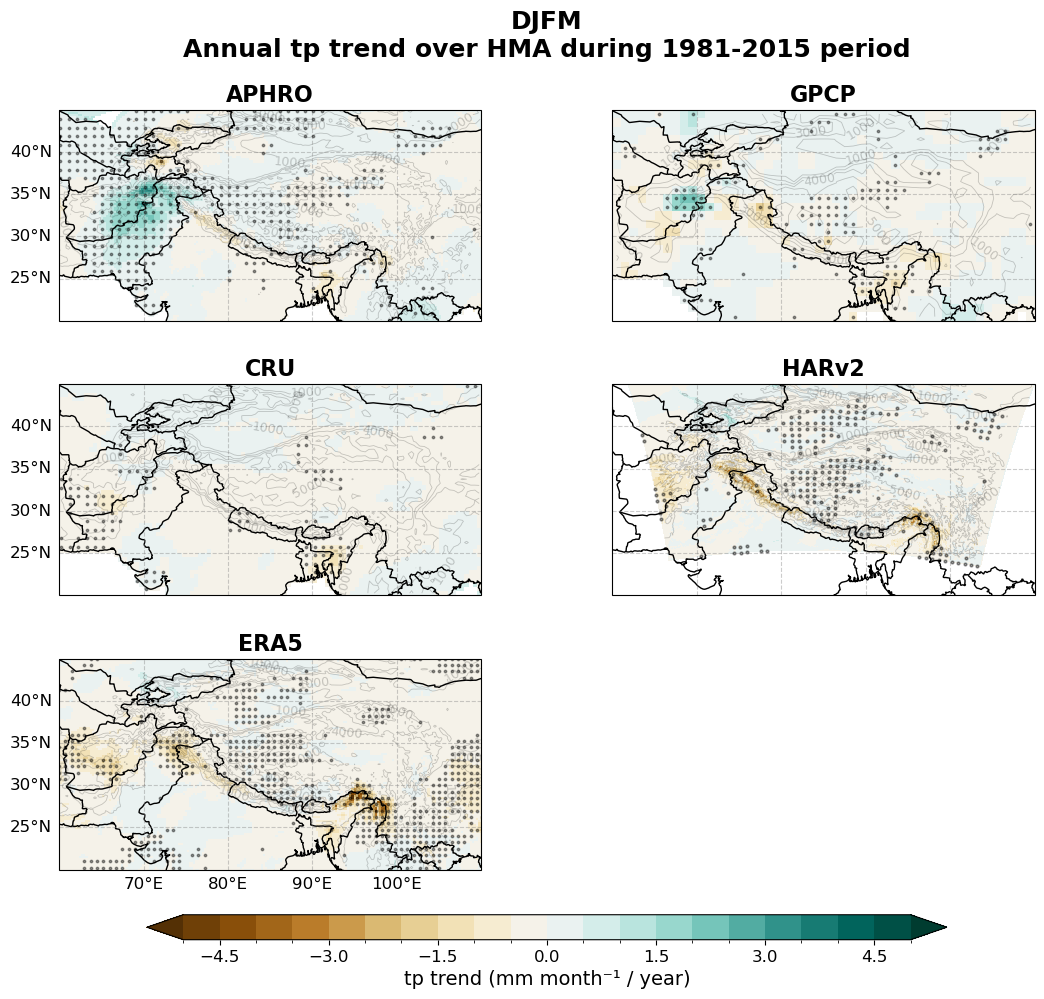

In [72]:
step_p = {
    models[0]: 4,
    models[1]: 1,
    models[2]: 2,
    models[3]: 8,
    models[4]: 3}

step = 0.5
vmax = 5
#vmax = max(np.round(float(np.nanmax(np.abs(ds))), 1) for ds in trend_annual_dict.values())
print(vmax)
levels = np.linspace(-vmax, vmax, int(2*vmax/step)+1)
cmap = plt.get_cmap("BrBG", len(levels)-1+2)
norm = mcolors.BoundaryNorm(levels, ncolors=cmap.N, extend='both')

fig, axes = plt.subplots(3, 2, figsize=(16, 10), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, (ax, model) in enumerate(zip(axes, models)):
    #model = models[i]
    data_model = trend_seasonal_dict[model]

    im = ax.pcolormesh(data_model['lon'],data_model['lat'],data_model,transform=ccrs.PlateCarree(),cmap=cmap,norm=norm,shading="auto")

    sig = p_annual_dict[model] < 0.05 
    step = step_p[model]
    if model == 'HARv2':
        lon2d = data_model['lon'].values
        lat2d = data_model['lat'].values
        mask = sig.values
        ax.scatter(lon2d[::step, ::step][mask[::step, ::step]],lat2d[::step, ::step][mask[::step, ::step]],
                    color='black',s=4,marker='o',transform=ccrs.PlateCarree(),zorder=5,alpha=0.4)
    else:
        lon_sig, lat_sig = data_model['lon'].values, data_model['lat'].values
        lon_grid, lat_grid = np.meshgrid(lon_sig, lat_sig)
        ax.scatter(lon_grid[::step, ::step][np.where(sig[::step, ::step])],lat_grid[::step, ::step][np.where(sig[::step, ::step])],
               color='black', s=3, marker='o', transform=ccrs.PlateCarree(), zorder=5, alpha=0.4)
    
    ax.set_extent([lonW,lonE,latS,latN], crs=ccrs.PlateCarree())
    
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle="-")

    SH = ax.contour(field_SH_dict[model].lon,field_SH_dict[model].lat,field_SH_dict[model],levels=[1000,2000,3000,4000,5000,6000,7000],
                colors="k",linewidths=0.6,alpha=0.2,transform=ccrs.PlateCarree())
    ax.clabel(SH, inline=True, fontsize=9, fmt="%d")
    
    ax.set_title(model, fontsize=16, weight="bold")

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 2 == 0)
    gl.bottom_labels = (i >= 4) 
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

# Supprimer les axes inutilisés
for j in range(len(models), len(axes)):
    fig.delaxes(axes[j])
    
cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='both')
cbar.set_label("tp trend (mm month⁻¹ / year)", fontsize=14)
cbar.ax.tick_params(labelsize=12)

fig.subplots_adjust(left=0.08, right=0.92, top=0.88, bottom=0.12, wspace=-0.3, hspace=0.3)
plt.suptitle(f"{season}\nAnnual tp trend over HMA during {iyear}-{fyear} period", fontsize=18, weight="bold")

plt.show()

# AM

In [81]:
trend_seasonal_dict={}
p_seasonal_dict={}
season='AM'
output_dir = '/bettik/PROJECTS/pr-regional-climate/bricej/climbas/'
var_names = ['trend', 'intercept', 'rvalue', 'pvalue', 'stderr']

In [74]:
#======================== APHRO ========================================================

tp_seasonal1,_ = seasonal_selection(field1, season, iyear, fyear)
par1 = trend_vect(tp_seasonal1.time,tp_seasonal1,dim='time')

ds = xr.Dataset({name: da for name, da in zip(var_names, par1)})
ds.attrs["description"] = "tp annual linregress over 1981–2015 in HMA"
filename = f"{output_dir}/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_APHRO.nc"
ds.to_netcdf(filename)
print(f'Saved file : {filename}')

#======================== GPCP ========================================================


tp_seasonal2,_ = seasonal_selection(field2, season, iyear, fyear)
par2 = trend_vect(tp_seasonal2.time,tp_seasonal2,dim='time')

ds = xr.Dataset({name: da for name, da in zip(var_names, par2)})
ds.attrs["description"] = "tp annual linregress over 1981–2015 in HMA"
filename = f"{output_dir}/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_GPCP.nc"
ds.to_netcdf(filename)
print(f'Saved file : {filename}')

#======================== CRU ========================================================

tp_seasonal3,_ = seasonal_selection(field3, season, iyear, fyear)
par3 = trend_vect(tp_seasonal3.time,tp_seasonal3,dim='time')

ds = xr.Dataset({name: da for name, da in zip(var_names, par3)})
ds.attrs["description"] = "tp annual linregress over 1981–2015 in HMA"
filename = f"{output_dir}/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_CRU.nc"
ds.to_netcdf(filename)
print(f'Saved file : {filename}')

#======================== CHIRPS ========================================================

#tp_seasonal4,_ = seasonal_selection_chunk(field4, season, iyear, fyear)
#par4 = trend_vect(tp_seasonal4.time,tp_seasonal4,dim='time')

#ds = xr.Dataset({name: da for name, da in zip(var_names, par4)})
#ds.attrs["description"] = "tp annual linregress over 1981–2015 in HMA"
#filename = f"{output_dir}/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_CHIRPS.nc"
#ds.to_netcdf(filename)
#print(f'Saved file : {filename}')

#======================== HARv2 ========================================================

tp_annual5,_ = seasonal_selection(field5, season, iyear, fyear)
tp_annual5 = tp_annual5.assign_coords(
    lat = field5.lat,
    lon = field5.lon
)
par5 = trend_vect(tp_annual5.time,tp_annual5,dim='time')

ds = xr.Dataset({name: da for name, da in zip(var_names, par5)})
ds.attrs["description"] = "tp annual linregress over 1981–2015 in HMA"
filename = f"{output_dir}/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_HARv2.nc"
ds.to_netcdf(filename)
print(f'Saved file : {filename}')

#======================== ERA5 ========================================================

tp_seasonal6,_ = seasonal_selection(field6, season, iyear, fyear)
par6 = trend_vect(tp_seasonal6.time,tp_seasonal6,dim='time')

ds = xr.Dataset({name: da for name, da in zip(var_names, par6)})
ds.attrs["description"] = "tp annual linregress over 1981–2015 in HMA"
filename = f"{output_dir}/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_ERA5.nc"
ds.to_netcdf(filename)
print(f'Saved file : {filename}')

Saved file : /bettik/PROJECTS/pr-regional-climate/bricej/climbas//spatial_trend_tp_AM_HMA_1981-2015_APHRO.nc
Saved file : /bettik/PROJECTS/pr-regional-climate/bricej/climbas//spatial_trend_tp_AM_HMA_1981-2015_GPCP.nc
Saved file : /bettik/PROJECTS/pr-regional-climate/bricej/climbas//spatial_trend_tp_AM_HMA_1981-2015_CRU.nc
(D- 1981  JF- 1982  to D- 2015 JF- 2016
Saved file : /bettik/PROJECTS/pr-regional-climate/bricej/climbas//spatial_trend_tp_AM_HMA_1981-2015_HARv2.nc
Saved file : /bettik/PROJECTS/pr-regional-climate/bricej/climbas//spatial_trend_tp_AM_HMA_1981-2015_ERA5.nc


In [82]:
trend_seasonal_dict={}
p_seasonal_dict={}

models = ['APHRO','GPCP','CRU','HARv2','ERA5']

model1='APHRO'
par1 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/climbas/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_{model1}.nc')
trend1 = par1['trend'];p1 = par1['pvalue']
trend_seasonal_dict[models[0]] = trend1
p_seasonal_dict[models[0]] = p1

model2='GPCP'
par2 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/climbas/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_{model2}.nc')
trend2 = par2['trend'];p2 = par2['pvalue']
trend_seasonal_dict[models[1]] = trend2
p_seasonal_dict[models[1]] = p2

model3='CRU'
par3 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/climbas/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_{model3}.nc')
trend3 = par3['trend'];p3 = par3['pvalue']
trend_seasonal_dict[models[2]] = trend3
p_seasonal_dict[models[2]] = p3

model4='HARv2'
par4 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/climbas/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_{model4}.nc')
trend4 = par4['trend'];p4 = par4['pvalue']
trend_seasonal_dict[models[3]] = trend4
p_seasonal_dict[models[3]] = p4

model5='ERA5'
par5 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/climbas/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_{model5}.nc')
trend5 = par5['trend'];p5 = par5['pvalue']
trend_seasonal_dict[models[4]] = trend5
p_seasonal_dict[models[4]] = p5

5


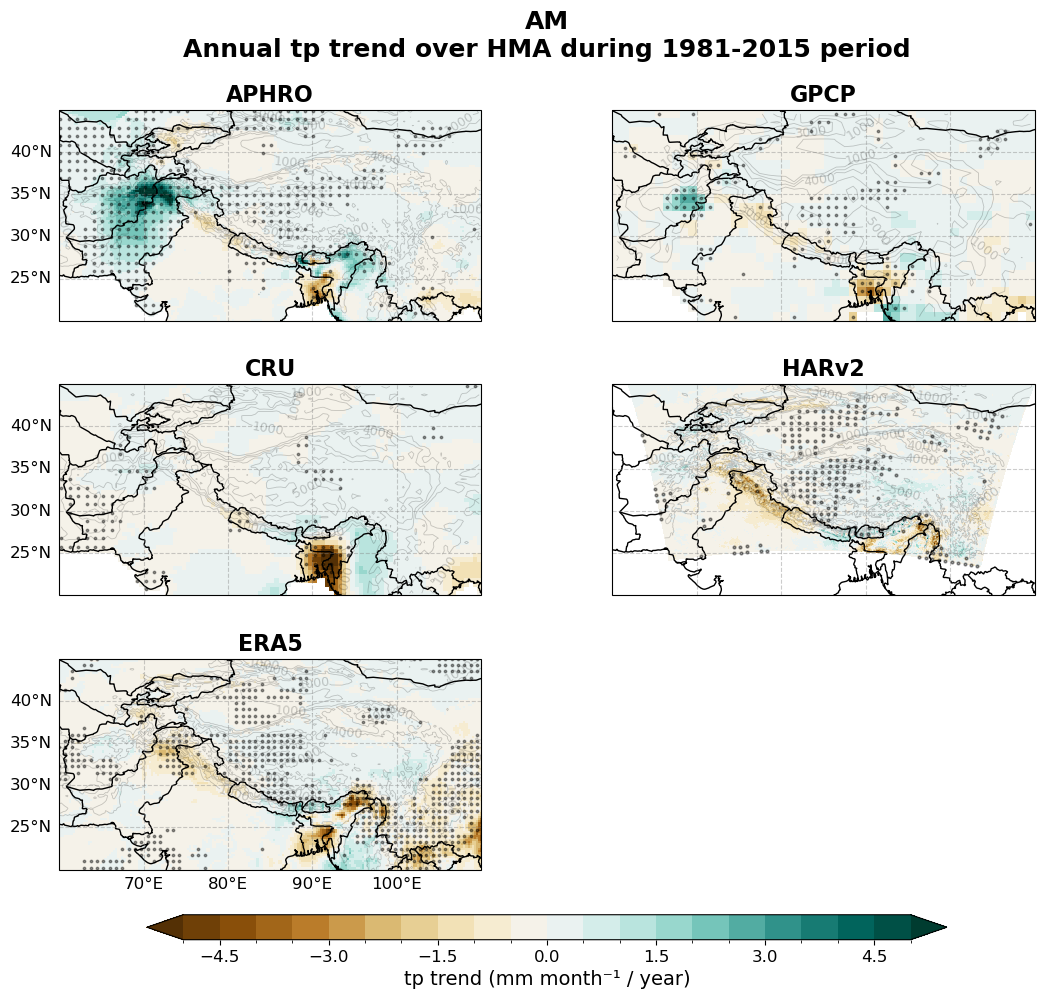

In [83]:
step_p = {
    models[0]: 4,
    models[1]: 1,
    models[2]: 2,
    models[3]: 8,
    models[4]: 3}

step = 0.5
vmax = 5
#vmax = max(np.round(float(np.nanmax(np.abs(ds))), 1) for ds in trend_annual_dict.values())
print(vmax)
levels = np.linspace(-vmax, vmax, int(2*vmax/step)+1)
cmap = plt.get_cmap("BrBG", len(levels)-1+2)
norm = mcolors.BoundaryNorm(levels, ncolors=cmap.N, extend='both')

fig, axes = plt.subplots(3, 2, figsize=(16, 10), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, (ax, model) in enumerate(zip(axes, models)):
    #model = models[i]
    data_model = trend_seasonal_dict[model]

    im = ax.pcolormesh(data_model['lon'],data_model['lat'],data_model,transform=ccrs.PlateCarree(),cmap=cmap,norm=norm,shading="auto")

    sig = p_annual_dict[model] < 0.05 
    step = step_p[model]
    if model == 'HARv2':
        lon2d = data_model['lon'].values
        lat2d = data_model['lat'].values
        mask = sig.values
        ax.scatter(lon2d[::step, ::step][mask[::step, ::step]],lat2d[::step, ::step][mask[::step, ::step]],
                    color='black',s=4,marker='o',transform=ccrs.PlateCarree(),zorder=5,alpha=0.4)
    else:
        lon_sig, lat_sig = data_model['lon'].values, data_model['lat'].values
        lon_grid, lat_grid = np.meshgrid(lon_sig, lat_sig)
        ax.scatter(lon_grid[::step, ::step][np.where(sig[::step, ::step])],lat_grid[::step, ::step][np.where(sig[::step, ::step])],
               color='black', s=3, marker='o', transform=ccrs.PlateCarree(), zorder=5, alpha=0.4)
    
    ax.set_extent([lonW,lonE,latS,latN], crs=ccrs.PlateCarree())
    
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle="-")

    SH = ax.contour(field_SH_dict[model].lon,field_SH_dict[model].lat,field_SH_dict[model],levels=[1000,2000,3000,4000,5000,6000,7000],
                colors="k",linewidths=0.6,alpha=0.2,transform=ccrs.PlateCarree())
    ax.clabel(SH, inline=True, fontsize=9, fmt="%d")
    
    ax.set_title(model, fontsize=16, weight="bold")

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 2 == 0)
    gl.bottom_labels = (i >= 4) 
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

# Supprimer les axes inutilisés
for j in range(len(models), len(axes)):
    fig.delaxes(axes[j])
    
cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='both')
cbar.set_label("tp trend (mm month⁻¹ / year)", fontsize=14)
cbar.ax.tick_params(labelsize=12)

fig.subplots_adjust(left=0.08, right=0.92, top=0.88, bottom=0.12, wspace=-0.3, hspace=0.3)
plt.suptitle(f"{season}\nAnnual tp trend over HMA during {iyear}-{fyear} period", fontsize=18, weight="bold")

plt.show()

# JJAS

In [84]:
trend_seasonal_dict={}
p_seasonal_dict={}
season='JJAS'
output_dir = '/bettik/PROJECTS/pr-regional-climate/bricej/climbas/'
var_names = ['trend', 'intercept', 'rvalue', 'pvalue', 'stderr']

In [78]:
#======================== APHRO ========================================================

tp_seasonal1,_ = seasonal_selection(field1, season, iyear, fyear)
par1 = trend_vect(tp_seasonal1.time,tp_seasonal1,dim='time')

ds = xr.Dataset({name: da for name, da in zip(var_names, par1)})
ds.attrs["description"] = "tp annual linregress over 1981–2015 in HMA"
filename = f"{output_dir}/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_APHRO.nc"
ds.to_netcdf(filename)
print(f'Saved file : {filename}')

#======================== GPCP ========================================================


tp_seasonal2,_ = seasonal_selection(field2, season, iyear, fyear)
par2 = trend_vect(tp_seasonal2.time,tp_seasonal2,dim='time')

ds = xr.Dataset({name: da for name, da in zip(var_names, par2)})
ds.attrs["description"] = "tp annual linregress over 1981–2015 in HMA"
filename = f"{output_dir}/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_GPCP.nc"
ds.to_netcdf(filename)
print(f'Saved file : {filename}')

#======================== CRU ========================================================

tp_seasonal3,_ = seasonal_selection(field3, season, iyear, fyear)
par3 = trend_vect(tp_seasonal3.time,tp_seasonal3,dim='time')

ds = xr.Dataset({name: da for name, da in zip(var_names, par3)})
ds.attrs["description"] = "tp annual linregress over 1981–2015 in HMA"
filename = f"{output_dir}/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_CRU.nc"
ds.to_netcdf(filename)
print(f'Saved file : {filename}')

#======================== CHIRPS ========================================================

#tp_seasonal4,_ = seasonal_selection_chunk(field4, season, iyear, fyear)
#par4 = trend_vect(tp_seasonal4.time,tp_seasonal4,dim='time')

#ds = xr.Dataset({name: da for name, da in zip(var_names, par4)})
#ds.attrs["description"] = "tp annual linregress over 1981–2015 in HMA"
#filename = f"{output_dir}/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_CHIRPS.nc"
#ds.to_netcdf(filename)
#print(f'Saved file : {filename}')

#======================== HARv2 ========================================================

tp_annual5,_ = seasonal_selection(field5, season, iyear, fyear)
tp_annual5 = tp_annual5.assign_coords(
    lat = field5.lat,
    lon = field5.lon
)
par5 = trend_vect(tp_annual5.time,tp_annual5,dim='time')

ds = xr.Dataset({name: da for name, da in zip(var_names, par5)})
ds.attrs["description"] = "tp annual linregress over 1981–2015 in HMA"
filename = f"{output_dir}/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_HARv2.nc"
ds.to_netcdf(filename)
print(f'Saved file : {filename}')

#======================== ERA5 ========================================================

tp_seasonal6,_ = seasonal_selection(field6, season, iyear, fyear)
par6 = trend_vect(tp_seasonal6.time,tp_seasonal6,dim='time')

ds = xr.Dataset({name: da for name, da in zip(var_names, par6)})
ds.attrs["description"] = "tp annual linregress over 1981–2015 in HMA"
filename = f"{output_dir}/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_ERA5.nc"
ds.to_netcdf(filename)
print(f'Saved file : {filename}')

Saved file : /bettik/PROJECTS/pr-regional-climate/bricej/climbas//spatial_trend_tp_JJAS_HMA_1981-2015_APHRO.nc
Saved file : /bettik/PROJECTS/pr-regional-climate/bricej/climbas//spatial_trend_tp_JJAS_HMA_1981-2015_GPCP.nc
Saved file : /bettik/PROJECTS/pr-regional-climate/bricej/climbas//spatial_trend_tp_JJAS_HMA_1981-2015_CRU.nc
(D- 1981  JF- 1982  to D- 2015 JF- 2016
Saved file : /bettik/PROJECTS/pr-regional-climate/bricej/climbas//spatial_trend_tp_JJAS_HMA_1981-2015_HARv2.nc
Saved file : /bettik/PROJECTS/pr-regional-climate/bricej/climbas//spatial_trend_tp_JJAS_HMA_1981-2015_ERA5.nc


In [86]:
trend_seasonal_dict={}
p_seasonal_dict={}

models = ['APHRO','GPCP','CRU','HARv2','ERA5']

model1='APHRO'
par1 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/climbas/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_{model1}.nc')
trend1 = par1['trend'];p1 = par1['pvalue']
trend_seasonal_dict[models[0]] = trend1
p_seasonal_dict[models[0]] = p1

model2='GPCP'
par2 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/climbas/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_{model2}.nc')
trend2 = par2['trend'];p2 = par2['pvalue']
trend_seasonal_dict[models[1]] = trend2
p_seasonal_dict[models[1]] = p2

model3='CRU'
par3 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/climbas/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_{model3}.nc')
trend3 = par3['trend'];p3 = par3['pvalue']
trend_seasonal_dict[models[2]] = trend3
p_seasonal_dict[models[2]] = p3

model4='HARv2'
par4 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/climbas/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_{model4}.nc')
trend4 = par4['trend'];p4 = par4['pvalue']
trend_seasonal_dict[models[3]] = trend4
p_seasonal_dict[models[3]] = p4

model5='ERA5'
par5 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/climbas/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_{model5}.nc')
trend5 = par5['trend'];p5 = par5['pvalue']
trend_seasonal_dict[models[4]] = trend5
p_seasonal_dict[models[4]] = p5

5


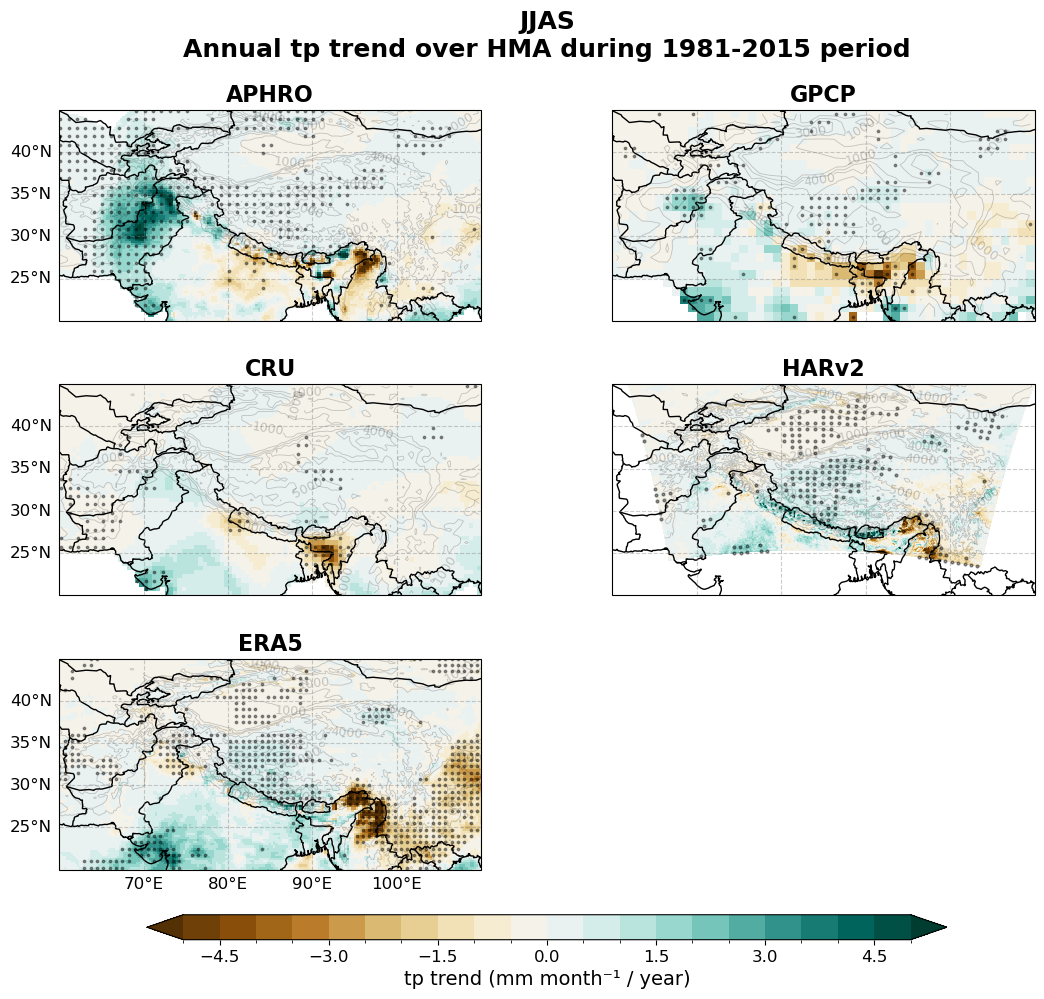

In [87]:
step_p = {
    models[0]: 4,
    models[1]: 1,
    models[2]: 2,
    models[3]: 8,
    models[4]: 3}

step = 0.5
vmax = 5
#vmax = max(np.round(float(np.nanmax(np.abs(ds))), 1) for ds in trend_annual_dict.values())
print(vmax)
levels = np.linspace(-vmax, vmax, int(2*vmax/step)+1)
cmap = plt.get_cmap("BrBG", len(levels)-1+2)
norm = mcolors.BoundaryNorm(levels, ncolors=cmap.N, extend='both')

fig, axes = plt.subplots(3, 2, figsize=(16, 10), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, (ax, model) in enumerate(zip(axes, models)):
    #model = models[i]
    data_model = trend_seasonal_dict[model]

    im = ax.pcolormesh(data_model['lon'],data_model['lat'],data_model,transform=ccrs.PlateCarree(),cmap=cmap,norm=norm,shading="auto")

    sig = p_annual_dict[model] < 0.05 
    step = step_p[model]
    if model == 'HARv2':
        lon2d = data_model['lon'].values
        lat2d = data_model['lat'].values
        mask = sig.values
        ax.scatter(lon2d[::step, ::step][mask[::step, ::step]],lat2d[::step, ::step][mask[::step, ::step]],
                    color='black',s=4,marker='o',transform=ccrs.PlateCarree(),zorder=5,alpha=0.4)
    else:
        lon_sig, lat_sig = data_model['lon'].values, data_model['lat'].values
        lon_grid, lat_grid = np.meshgrid(lon_sig, lat_sig)
        ax.scatter(lon_grid[::step, ::step][np.where(sig[::step, ::step])],lat_grid[::step, ::step][np.where(sig[::step, ::step])],
               color='black', s=3, marker='o', transform=ccrs.PlateCarree(), zorder=5, alpha=0.4)
    
    ax.set_extent([lonW,lonE,latS,latN], crs=ccrs.PlateCarree())
    
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle="-")

    SH = ax.contour(field_SH_dict[model].lon,field_SH_dict[model].lat,field_SH_dict[model],levels=[1000,2000,3000,4000,5000,6000,7000],
                colors="k",linewidths=0.6,alpha=0.2,transform=ccrs.PlateCarree())
    ax.clabel(SH, inline=True, fontsize=9, fmt="%d")
    
    ax.set_title(model, fontsize=16, weight="bold")

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 2 == 0)
    gl.bottom_labels = (i >= 4) 
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

# Supprimer les axes inutilisés
for j in range(len(models), len(axes)):
    fig.delaxes(axes[j])
    
cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='both')
cbar.set_label("tp trend (mm month⁻¹ / year)", fontsize=14)
cbar.ax.tick_params(labelsize=12)

fig.subplots_adjust(left=0.08, right=0.92, top=0.88, bottom=0.12, wspace=-0.3, hspace=0.3)
plt.suptitle(f"{season}\nAnnual tp trend over HMA during {iyear}-{fyear} period", fontsize=18, weight="bold")

plt.show()

# ON

In [88]:
trend_seasonal_dict={}
p_seasonal_dict={}
season='ON'
output_dir = '/bettik/PROJECTS/pr-regional-climate/bricej/climbas/'
var_names = ['trend', 'intercept', 'rvalue', 'pvalue', 'stderr']

In [89]:
#======================== APHRO ========================================================

tp_seasonal1,_ = seasonal_selection(field1, season, iyear, fyear)
par1 = trend_vect(tp_seasonal1.time,tp_seasonal1,dim='time')

ds = xr.Dataset({name: da for name, da in zip(var_names, par1)})
ds.attrs["description"] = "tp annual linregress over 1981–2015 in HMA"
filename = f"{output_dir}/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_APHRO.nc"
ds.to_netcdf(filename)
print(f'Saved file : {filename}')

#======================== GPCP ========================================================


tp_seasonal2,_ = seasonal_selection(field2, season, iyear, fyear)
par2 = trend_vect(tp_seasonal2.time,tp_seasonal2,dim='time')

ds = xr.Dataset({name: da for name, da in zip(var_names, par2)})
ds.attrs["description"] = "tp annual linregress over 1981–2015 in HMA"
filename = f"{output_dir}/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_GPCP.nc"
ds.to_netcdf(filename)
print(f'Saved file : {filename}')

#======================== CRU ========================================================

tp_seasonal3,_ = seasonal_selection(field3, season, iyear, fyear)
par3 = trend_vect(tp_seasonal3.time,tp_seasonal3,dim='time')

ds = xr.Dataset({name: da for name, da in zip(var_names, par3)})
ds.attrs["description"] = "tp annual linregress over 1981–2015 in HMA"
filename = f"{output_dir}/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_CRU.nc"
ds.to_netcdf(filename)
print(f'Saved file : {filename}')

#======================== CHIRPS ========================================================

#tp_seasonal4,_ = seasonal_selection_chunk(field4, season, iyear, fyear)
#par4 = trend_vect(tp_seasonal4.time,tp_seasonal4,dim='time')

#ds = xr.Dataset({name: da for name, da in zip(var_names, par4)})
#ds.attrs["description"] = "tp annual linregress over 1981–2015 in HMA"
#filename = f"{output_dir}/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_CHIRPS.nc"
#ds.to_netcdf(filename)
#print(f'Saved file : {filename}')

#======================== HARv2 ========================================================

tp_annual5,_ = seasonal_selection(field5, season, iyear, fyear)
tp_annual5 = tp_annual5.assign_coords(
    lat = field5.lat,
    lon = field5.lon
)
par5 = trend_vect(tp_annual5.time,tp_annual5,dim='time')

ds = xr.Dataset({name: da for name, da in zip(var_names, par5)})
ds.attrs["description"] = "tp annual linregress over 1981–2015 in HMA"
filename = f"{output_dir}/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_HARv2.nc"
ds.to_netcdf(filename)
print(f'Saved file : {filename}')

#======================== ERA5 ========================================================

tp_seasonal6,_ = seasonal_selection(field6, season, iyear, fyear)
par6 = trend_vect(tp_seasonal6.time,tp_seasonal6,dim='time')

ds = xr.Dataset({name: da for name, da in zip(var_names, par6)})
ds.attrs["description"] = "tp annual linregress over 1981–2015 in HMA"
filename = f"{output_dir}/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_ERA5.nc"
ds.to_netcdf(filename)
print(f'Saved file : {filename}')

Saved file : /bettik/PROJECTS/pr-regional-climate/bricej/climbas//spatial_trend_tp_ON_HMA_1981-2015_APHRO.nc
Saved file : /bettik/PROJECTS/pr-regional-climate/bricej/climbas//spatial_trend_tp_ON_HMA_1981-2015_GPCP.nc
Saved file : /bettik/PROJECTS/pr-regional-climate/bricej/climbas//spatial_trend_tp_ON_HMA_1981-2015_CRU.nc
Saved file : /bettik/PROJECTS/pr-regional-climate/bricej/climbas//spatial_trend_tp_ON_HMA_1981-2015_HARv2.nc
Saved file : /bettik/PROJECTS/pr-regional-climate/bricej/climbas//spatial_trend_tp_ON_HMA_1981-2015_ERA5.nc


In [90]:
trend_seasonal_dict={}
p_seasonal_dict={}

models = ['APHRO','GPCP','CRU','HARv2','ERA5']

model1='APHRO'
par1 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/climbas/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_{model1}.nc')
trend1 = par1['trend'];p1 = par1['pvalue']
trend_seasonal_dict[models[0]] = trend1
p_seasonal_dict[models[0]] = p1

model2='GPCP'
par2 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/climbas/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_{model2}.nc')
trend2 = par2['trend'];p2 = par2['pvalue']
trend_seasonal_dict[models[1]] = trend2
p_seasonal_dict[models[1]] = p2

model3='CRU'
par3 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/climbas/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_{model3}.nc')
trend3 = par3['trend'];p3 = par3['pvalue']
trend_seasonal_dict[models[2]] = trend3
p_seasonal_dict[models[2]] = p3

model4='HARv2'
par4 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/climbas/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_{model4}.nc')
trend4 = par4['trend'];p4 = par4['pvalue']
trend_seasonal_dict[models[3]] = trend4
p_seasonal_dict[models[3]] = p4

model5='ERA5'
par5 = xr.open_dataset(f'/bettik/PROJECTS/pr-regional-climate/bricej/climbas/spatial_trend_tp_{season}_{dom}_{iyear}-{fyear}_{model5}.nc')
trend5 = par5['trend'];p5 = par5['pvalue']
trend_seasonal_dict[models[4]] = trend5
p_seasonal_dict[models[4]] = p5

5


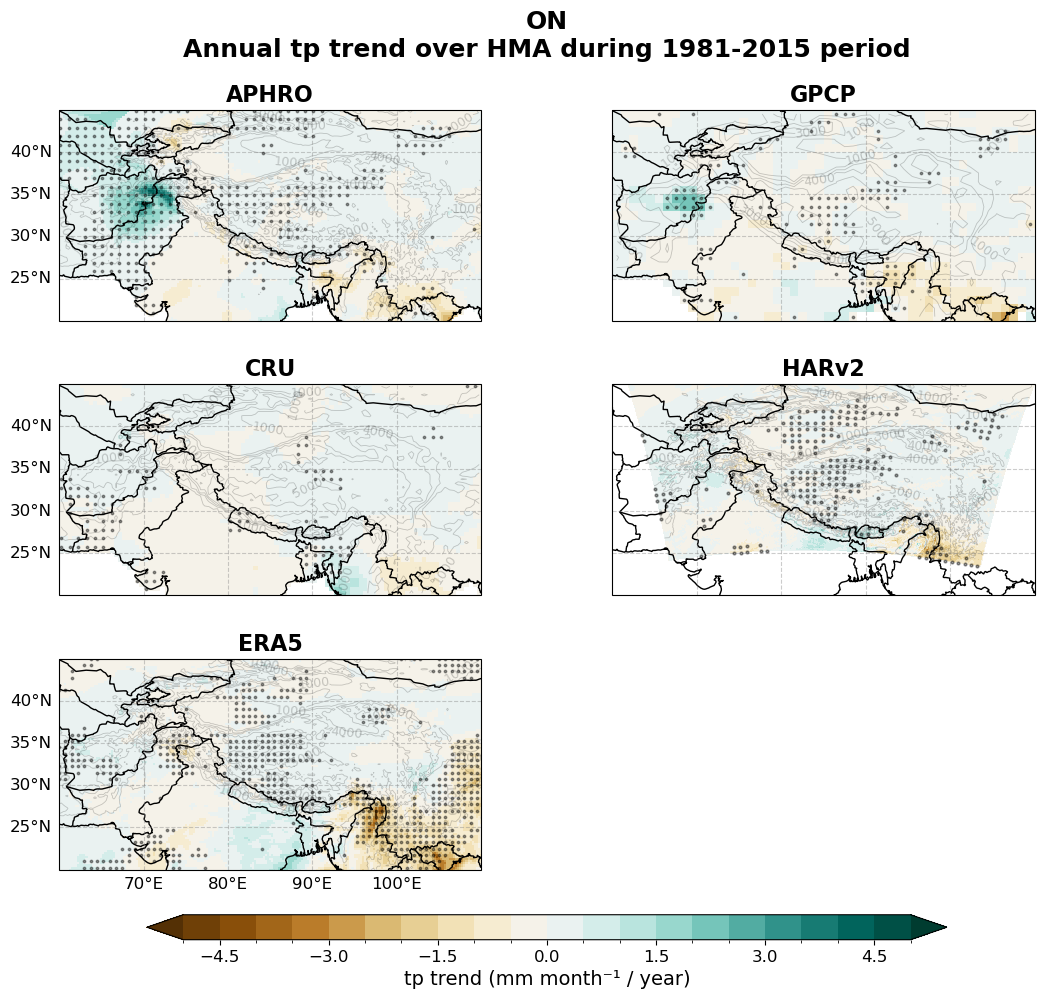

In [91]:
step_p = {
    models[0]: 4,
    models[1]: 1,
    models[2]: 2,
    models[3]: 8,
    models[4]: 3}

step = 0.5
vmax = 5
#vmax = max(np.round(float(np.nanmax(np.abs(ds))), 1) for ds in trend_annual_dict.values())
print(vmax)
levels = np.linspace(-vmax, vmax, int(2*vmax/step)+1)
cmap = plt.get_cmap("BrBG", len(levels)-1+2)
norm = mcolors.BoundaryNorm(levels, ncolors=cmap.N, extend='both')

fig, axes = plt.subplots(3, 2, figsize=(16, 10), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, (ax, model) in enumerate(zip(axes, models)):
    #model = models[i]
    data_model = trend_seasonal_dict[model]

    im = ax.pcolormesh(data_model['lon'],data_model['lat'],data_model,transform=ccrs.PlateCarree(),cmap=cmap,norm=norm,shading="auto")

    sig = p_annual_dict[model] < 0.05 
    step = step_p[model]
    if model == 'HARv2':
        lon2d = data_model['lon'].values
        lat2d = data_model['lat'].values
        mask = sig.values
        ax.scatter(lon2d[::step, ::step][mask[::step, ::step]],lat2d[::step, ::step][mask[::step, ::step]],
                    color='black',s=4,marker='o',transform=ccrs.PlateCarree(),zorder=5,alpha=0.4)
    else:
        lon_sig, lat_sig = data_model['lon'].values, data_model['lat'].values
        lon_grid, lat_grid = np.meshgrid(lon_sig, lat_sig)
        ax.scatter(lon_grid[::step, ::step][np.where(sig[::step, ::step])],lat_grid[::step, ::step][np.where(sig[::step, ::step])],
               color='black', s=3, marker='o', transform=ccrs.PlateCarree(), zorder=5, alpha=0.4)
    
    ax.set_extent([lonW,lonE,latS,latN], crs=ccrs.PlateCarree())
    
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle="-")

    SH = ax.contour(field_SH_dict[model].lon,field_SH_dict[model].lat,field_SH_dict[model],levels=[1000,2000,3000,4000,5000,6000,7000],
                colors="k",linewidths=0.6,alpha=0.2,transform=ccrs.PlateCarree())
    ax.clabel(SH, inline=True, fontsize=9, fmt="%d")
    
    ax.set_title(model, fontsize=16, weight="bold")

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 2 == 0)
    gl.bottom_labels = (i >= 4) 
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

# Supprimer les axes inutilisés
for j in range(len(models), len(axes)):
    fig.delaxes(axes[j])
    
cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='both')
cbar.set_label("tp trend (mm month⁻¹ / year)", fontsize=14)
cbar.ax.tick_params(labelsize=12)

fig.subplots_adjust(left=0.08, right=0.92, top=0.88, bottom=0.12, wspace=-0.3, hspace=0.3)
plt.suptitle(f"{season}\nAnnual tp trend over HMA during {iyear}-{fyear} period", fontsize=18, weight="bold")

plt.show()